In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/Action potential waveforms are state-dependent paper/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/')
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    plot_spike_to_avg_distances,
    plot_spike_feature_within_vs_between,
    plot_waveform_dist_kde,
    plot_waveform_dist_scatter,
    plot_waveform_dist_raincloud,
    plot_waveform_dist_sorted_dots,
)
import config
from config import SPE1_PICKLE_ROOT

In [2]:
cluster_pickle_dir = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles')
spike_fit_dir      = os.path.join(SPE1_PICKLE_ROOT, 'spike_fit_pickles')

In [3]:
df_master = compile_experiment_results(cluster_pickle_dir)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)
df_master = df_master.sort_values(['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])

## Spike-to-average vs between-cell waveform distances

Within = each individual spike vs its own cell's mean waveform (~167k spikes). Between = each spike vs every other cell's mean (~7M comparisons). Both are spike-to-average nRMSE/cos_sim.

[spike_to_avg] cache HIT — loading


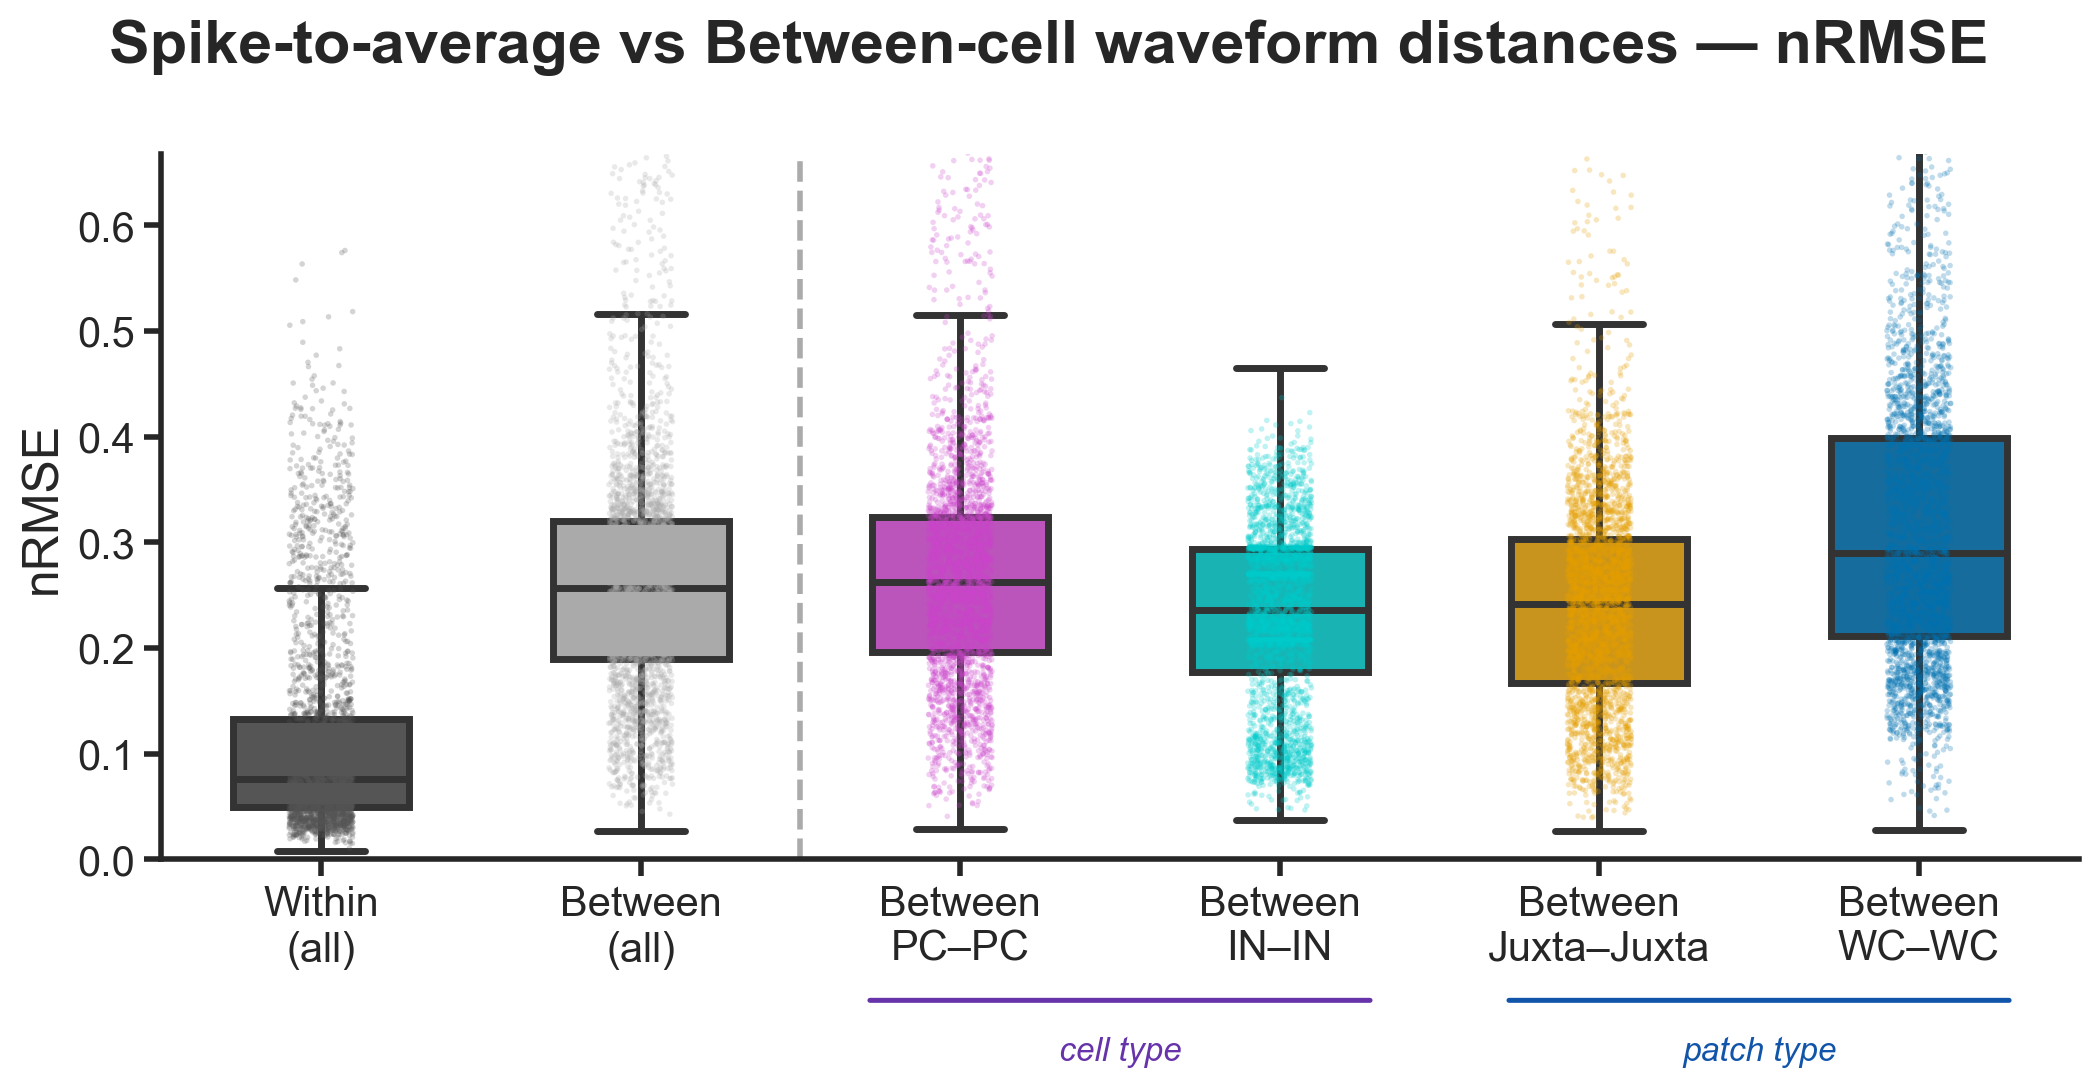


── nRMSE (spike-to-avg) ──
  Within (all)          : median=0.076  IQR=[0.050, 0.133]  n=167006
  Between (all)         : median=0.257  IQR=[0.189, 0.320]  n=200000
  Between PC–PC         : median=0.263  IQR=[0.197, 0.324]  n=200000
  Between IN–IN         : median=0.236  IQR=[0.178, 0.294]  n=200000
  Between Juxta–Juxta   : median=0.241  IQR=[0.167, 0.303]  n=200000
  Between WC–WC         : median=0.290  IQR=[0.211, 0.399]  n=77752


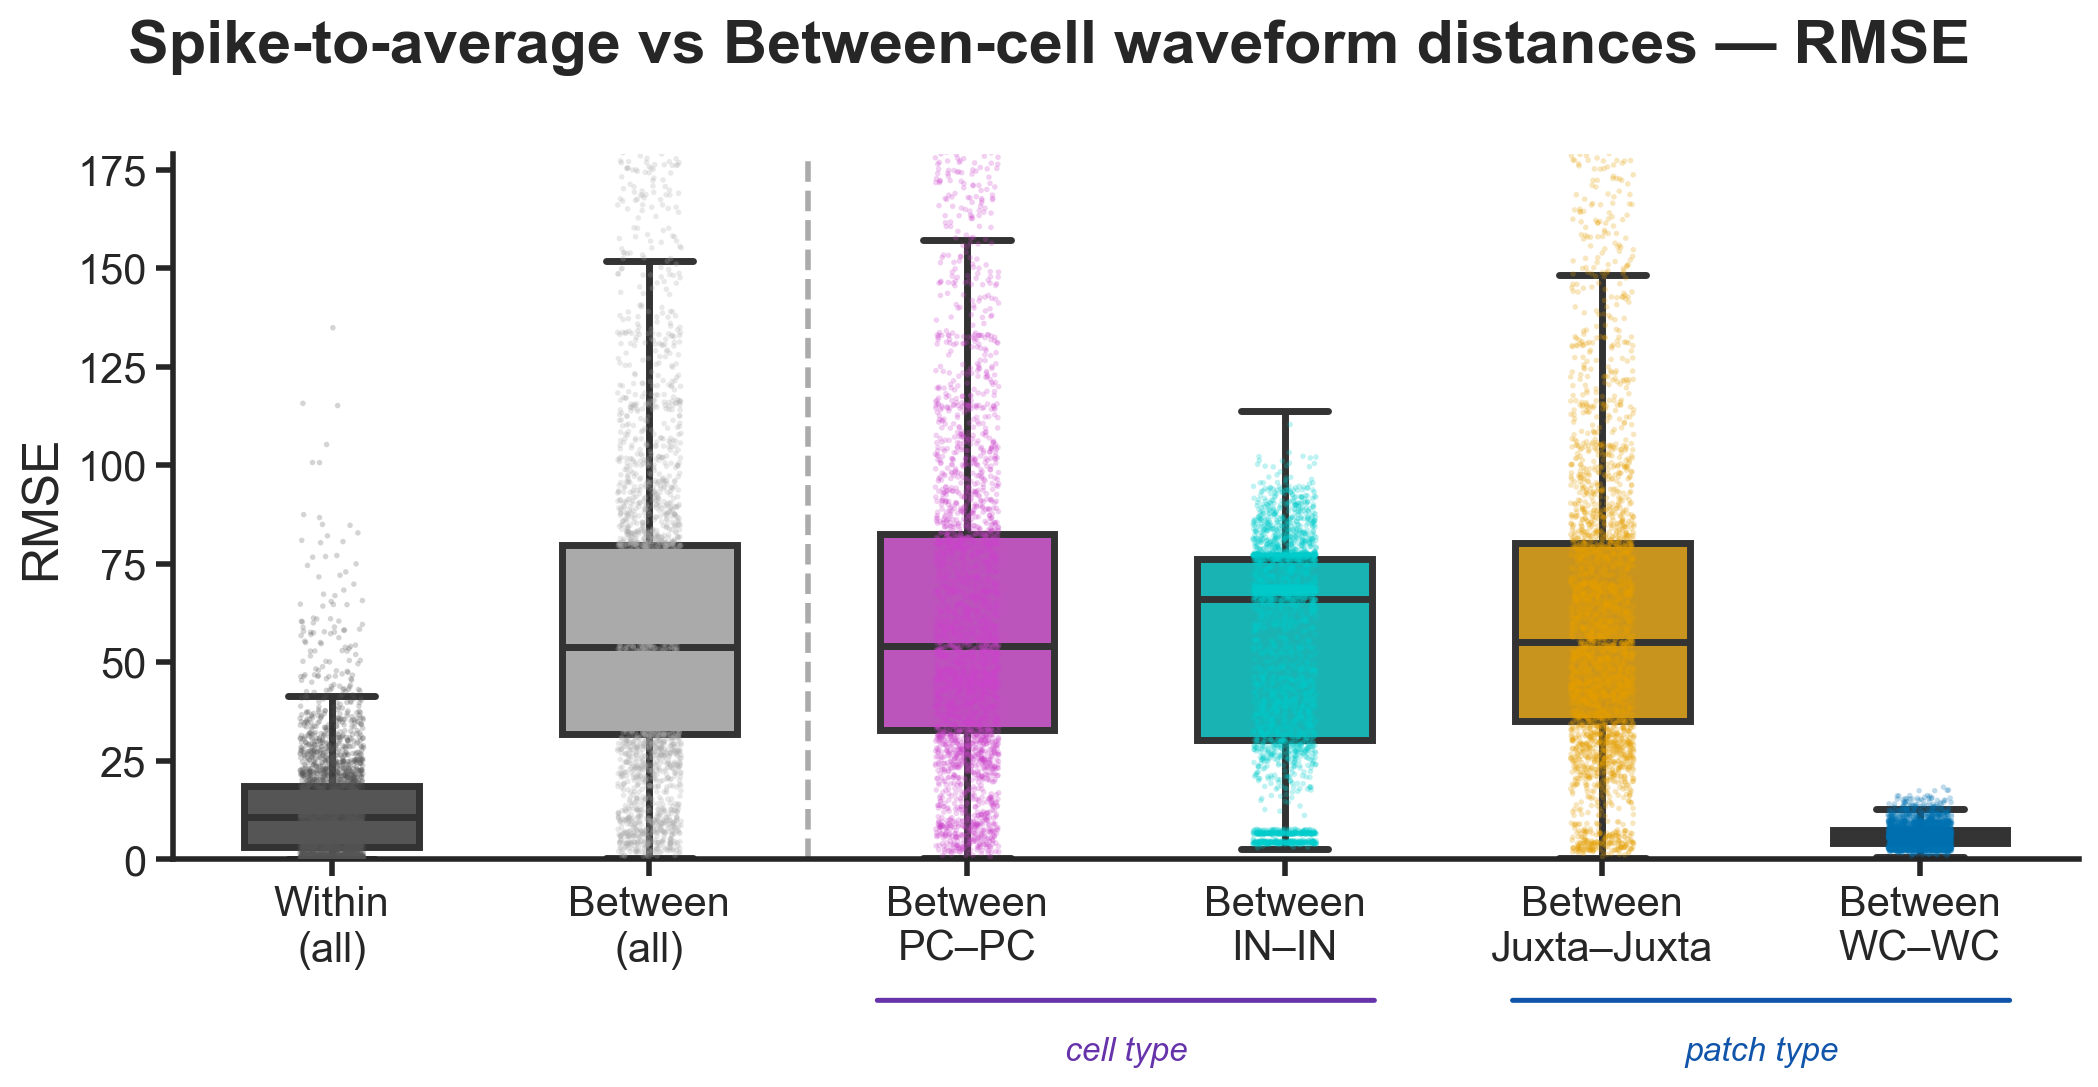


── RMSE (spike-to-avg) ──
  Within (all)          : median=10.807  IQR=[3.193, 18.527]  n=167006
  Between (all)         : median=53.757  IQR=[31.881, 79.829]  n=200000
  Between PC–PC         : median=54.194  IQR=[32.900, 82.664]  n=200000
  Between IN–IN         : median=65.950  IQR=[30.395, 76.129]  n=200000
  Between Juxta–Juxta   : median=55.177  IQR=[35.058, 80.324]  n=200000
  Between WC–WC         : median=5.766  IQR=[4.041, 7.521]  n=77752


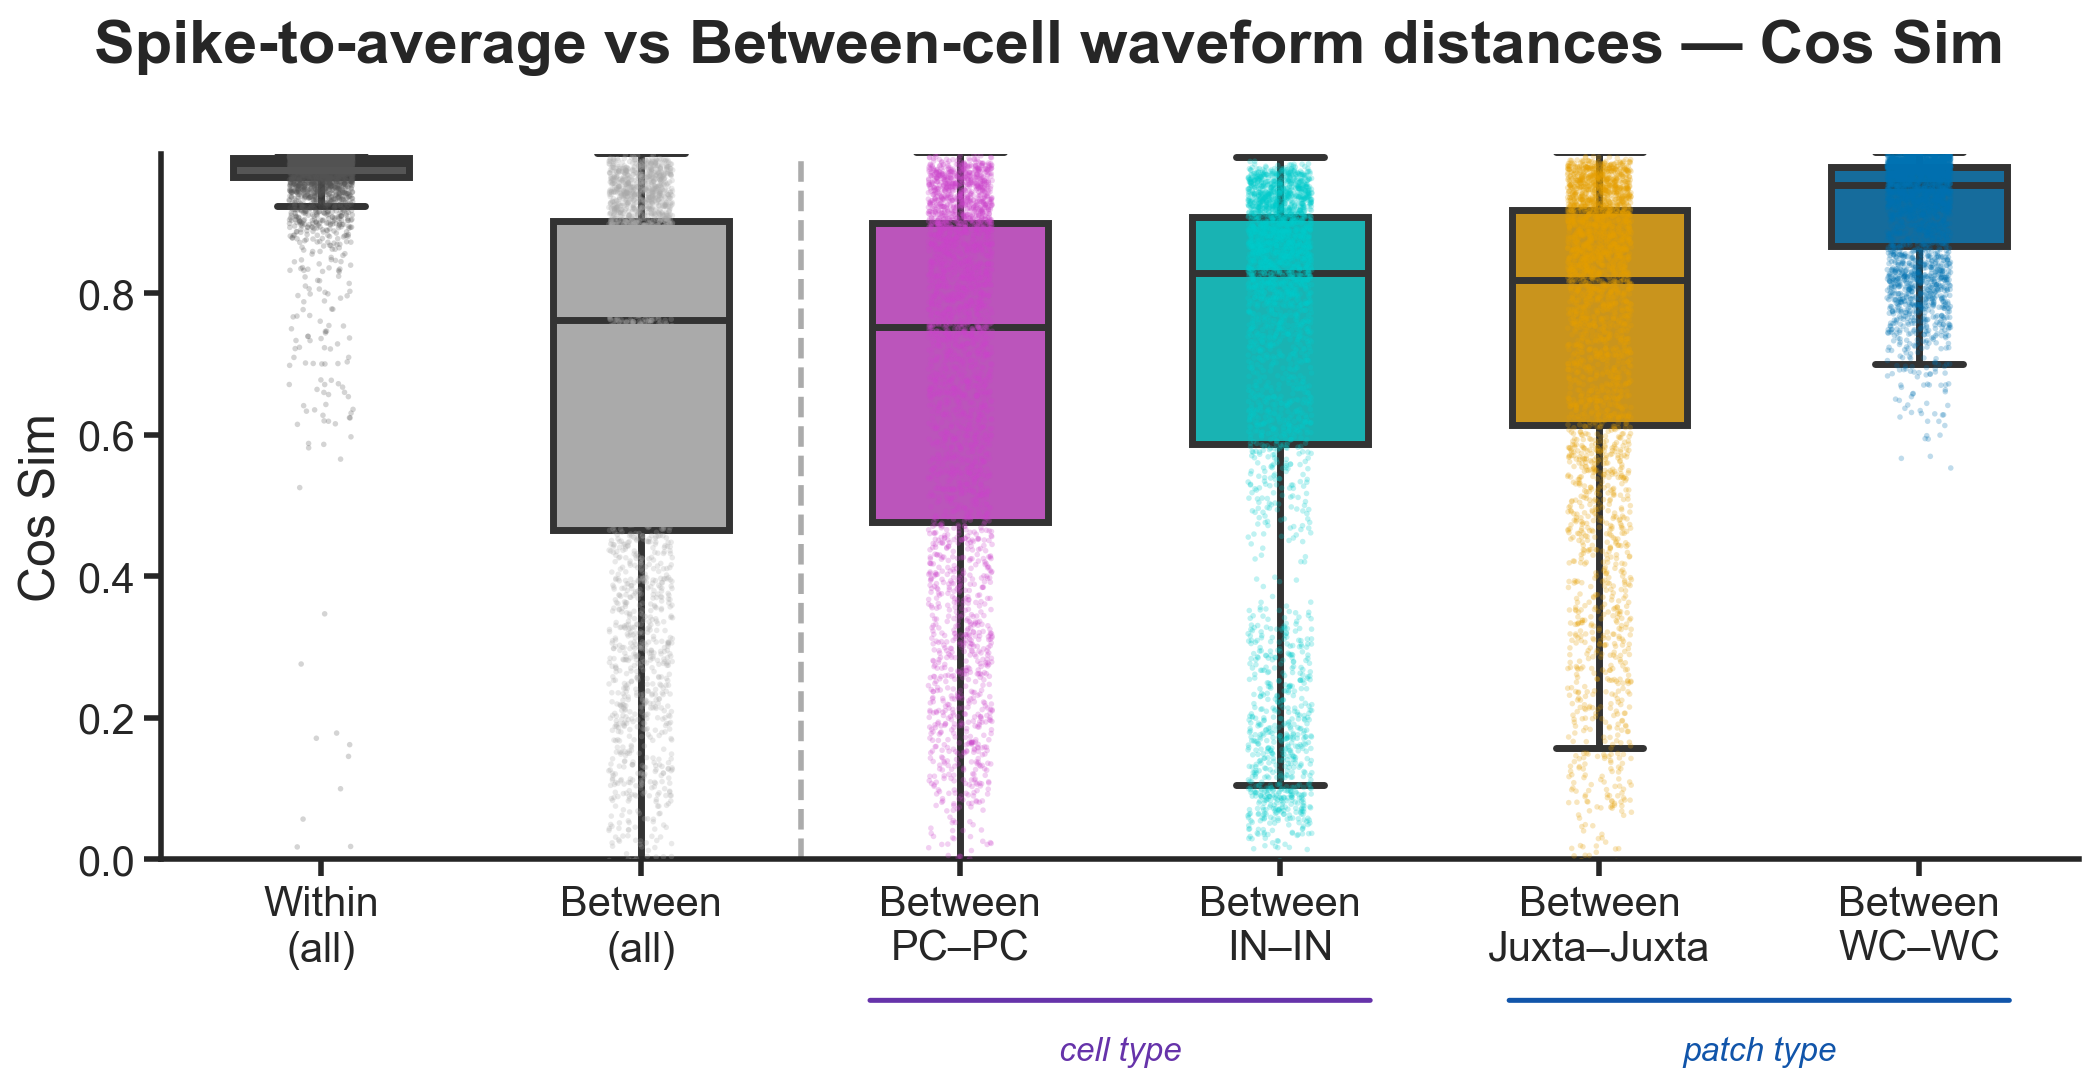


── Cos Sim (spike-to-avg) ──
  Within (all)          : median=0.984  IQR=[0.965, 0.992]  n=167006
  Between (all)         : median=0.762  IQR=[0.465, 0.903]  n=200000
  Between PC–PC         : median=0.752  IQR=[0.477, 0.900]  n=200000
  Between IN–IN         : median=0.828  IQR=[0.587, 0.908]  n=200000
  Between Juxta–Juxta   : median=0.819  IQR=[0.614, 0.918]  n=200000
  Between WC–WC         : median=0.953  IQR=[0.868, 0.979]  n=77752


In [4]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    spike_fit_dir=spike_fit_dir,
    half_win=75,
)

## Within vs between: waveform nRMSE per spike feature

For each waveform feature (cells with clustering for that feature only): within = waveform nRMSE of each spike vs its own cell's mean waveform; between = waveform nRMSE of each spike vs every other cell's mean waveform.

[spike_feature_wb] mode=simple  cache=HIT — loading
Loaded waveforms for 43 cells
  peak_amp: loaded from cache
  peak_sharpness: loaded from cache
  peak_width: loaded from cache
  exp_lambda: loaded from cache
  inflection_amp: loaded from cache
  inflection_time: loaded from cache


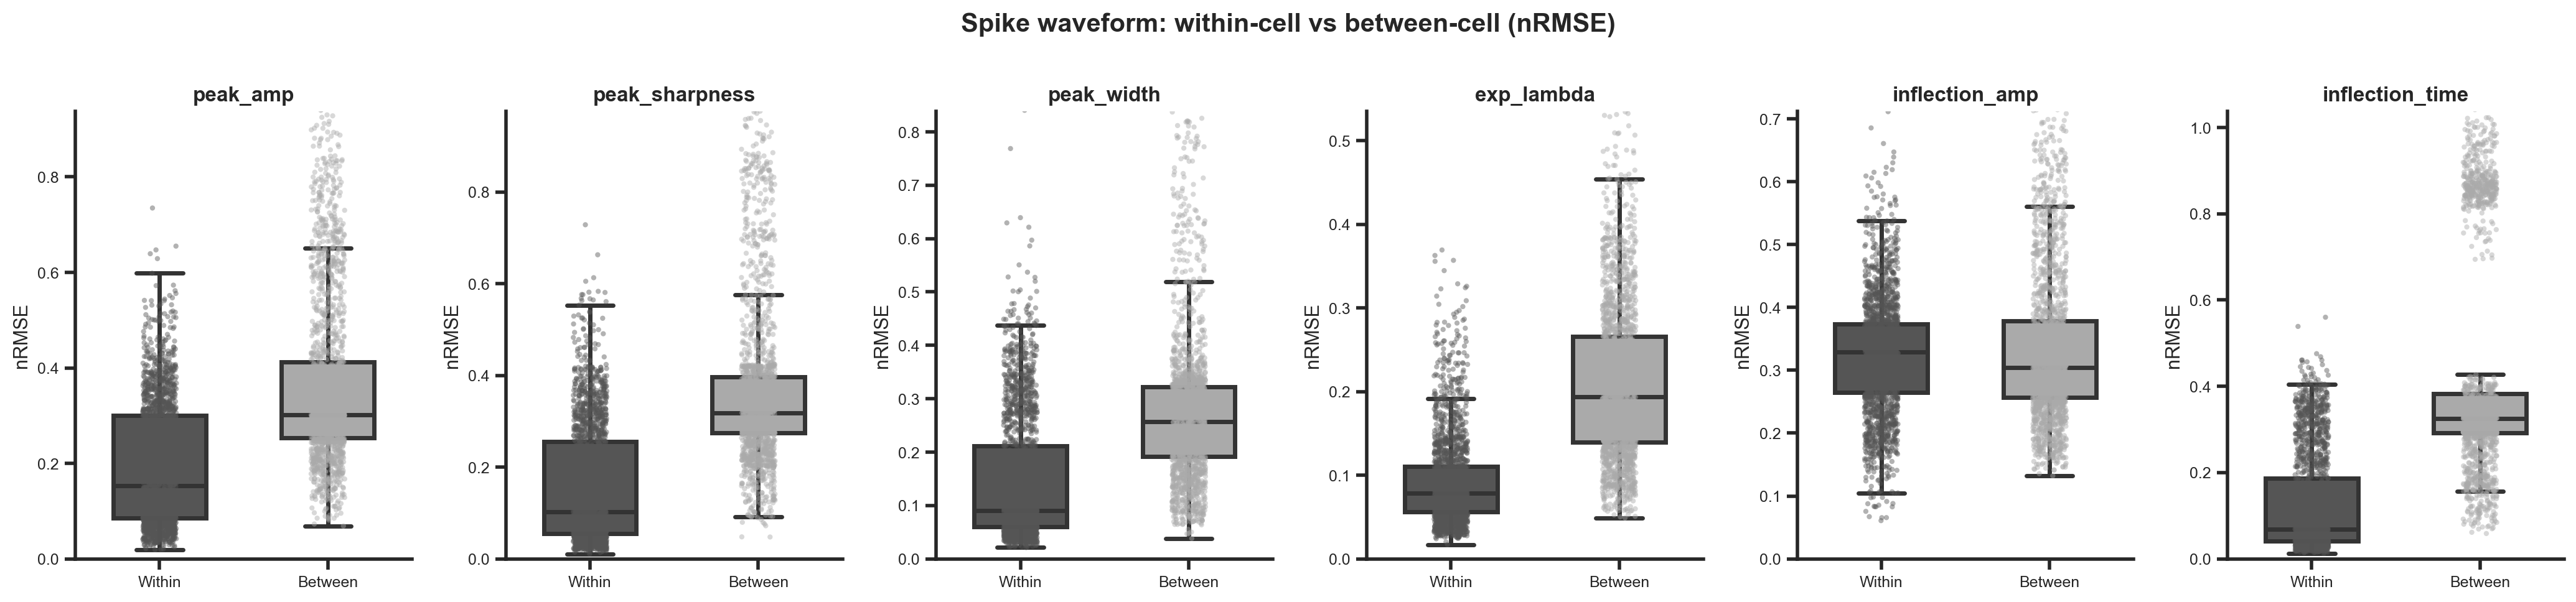

  peak_amp: loaded from cache
  peak_sharpness: loaded from cache
  peak_width: loaded from cache
  exp_lambda: loaded from cache
  inflection_amp: loaded from cache
  inflection_time: loaded from cache


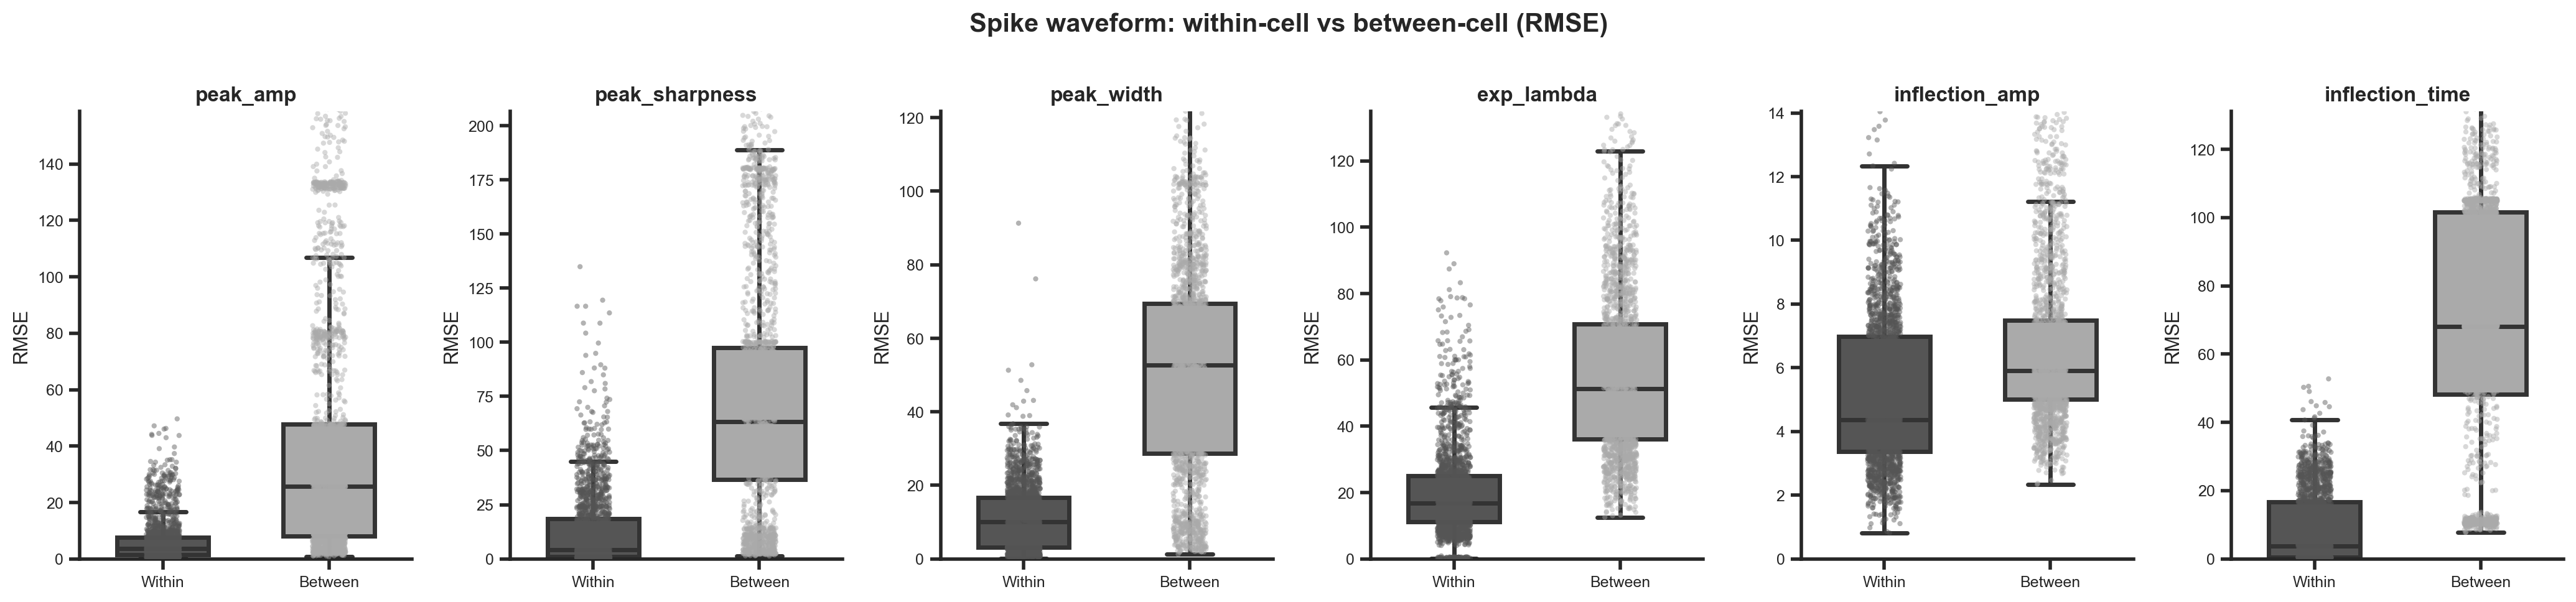

In [5]:
plot_spike_feature_within_vs_between(cluster_pickle_dir, spike_fit_dir)

[spike_feature_wb] mode=detailed  cache=HIT — loading
Loaded waveforms for 43 cells
  peak_amp: loaded from cache


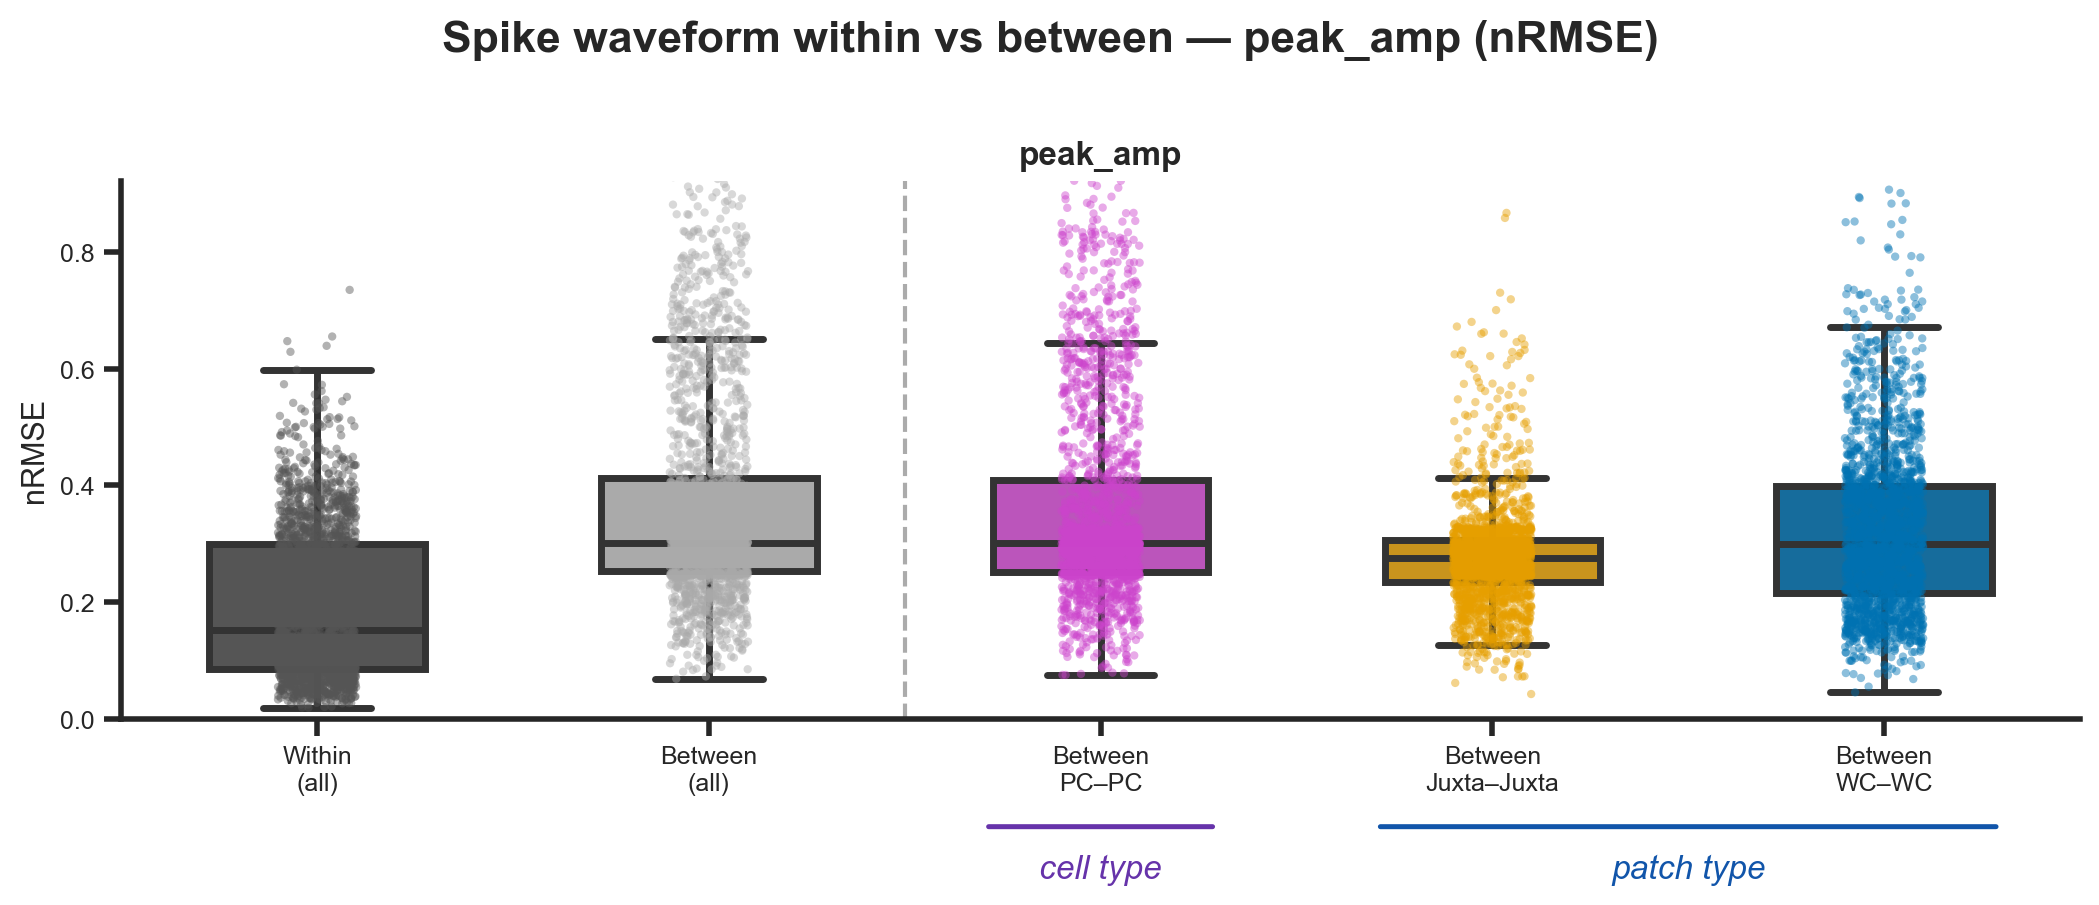

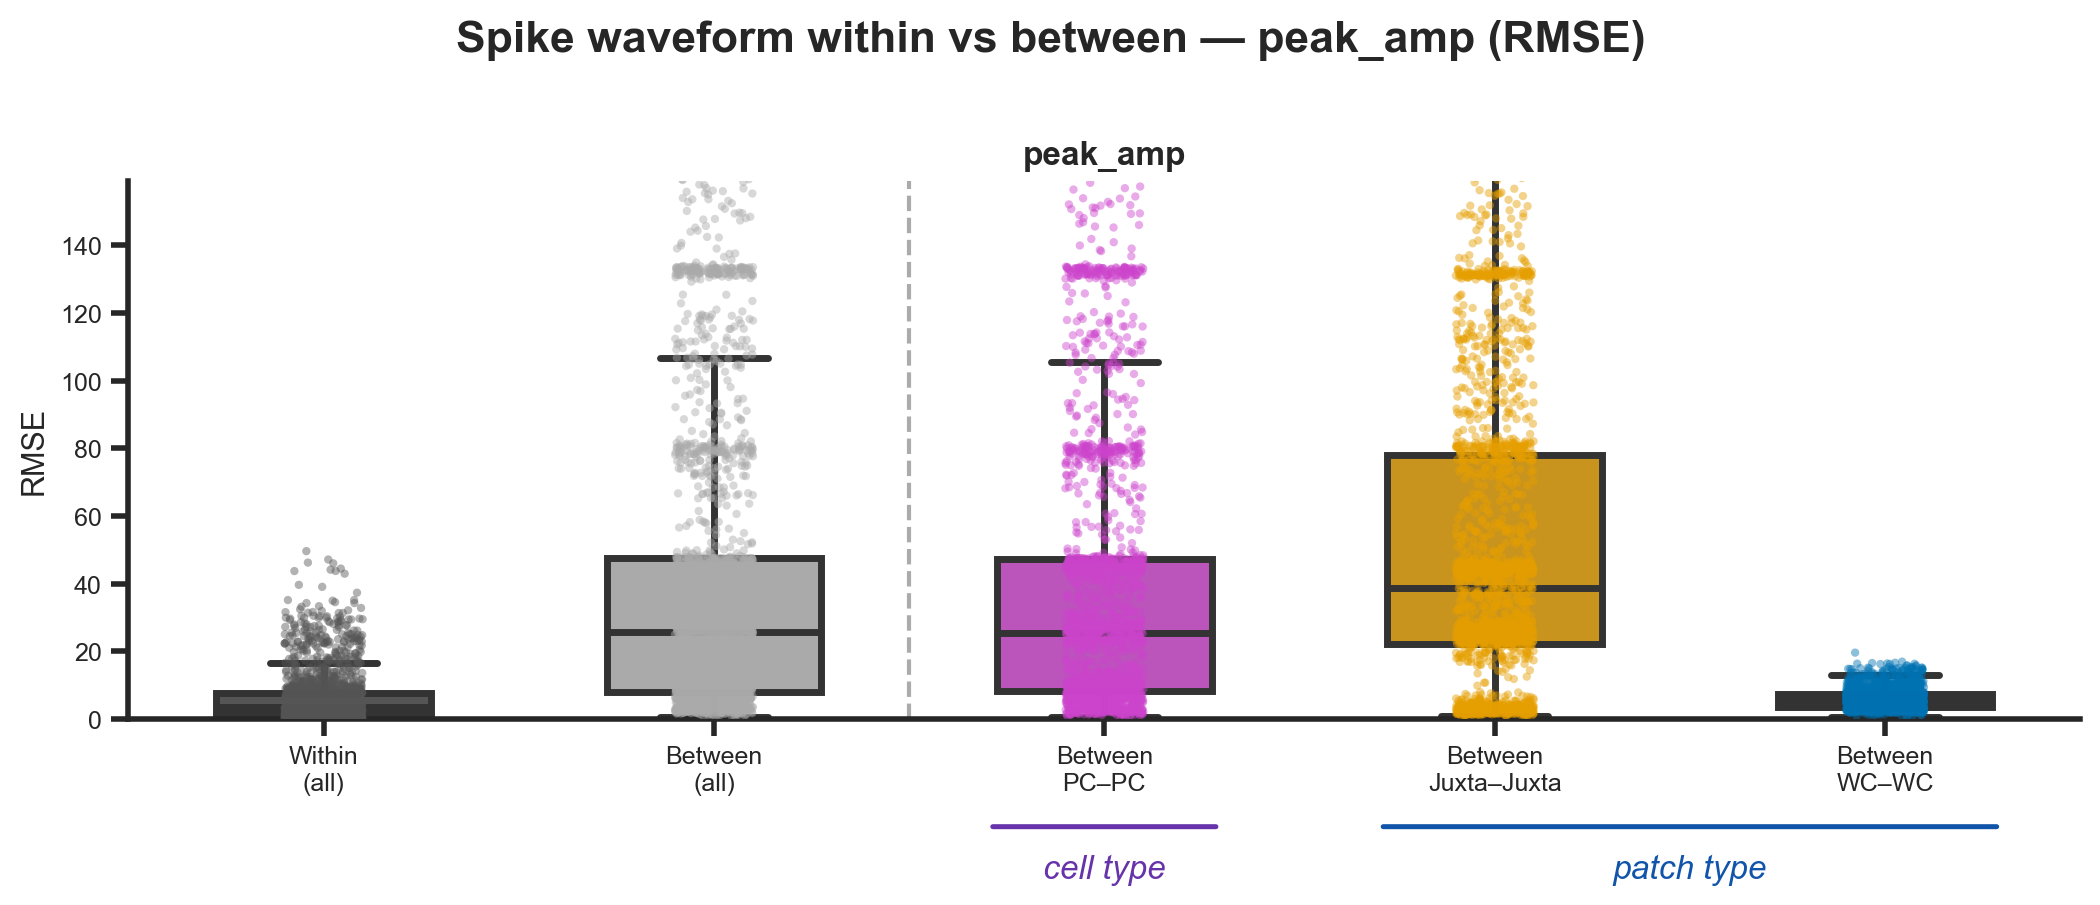

  peak_sharpness: loaded from cache


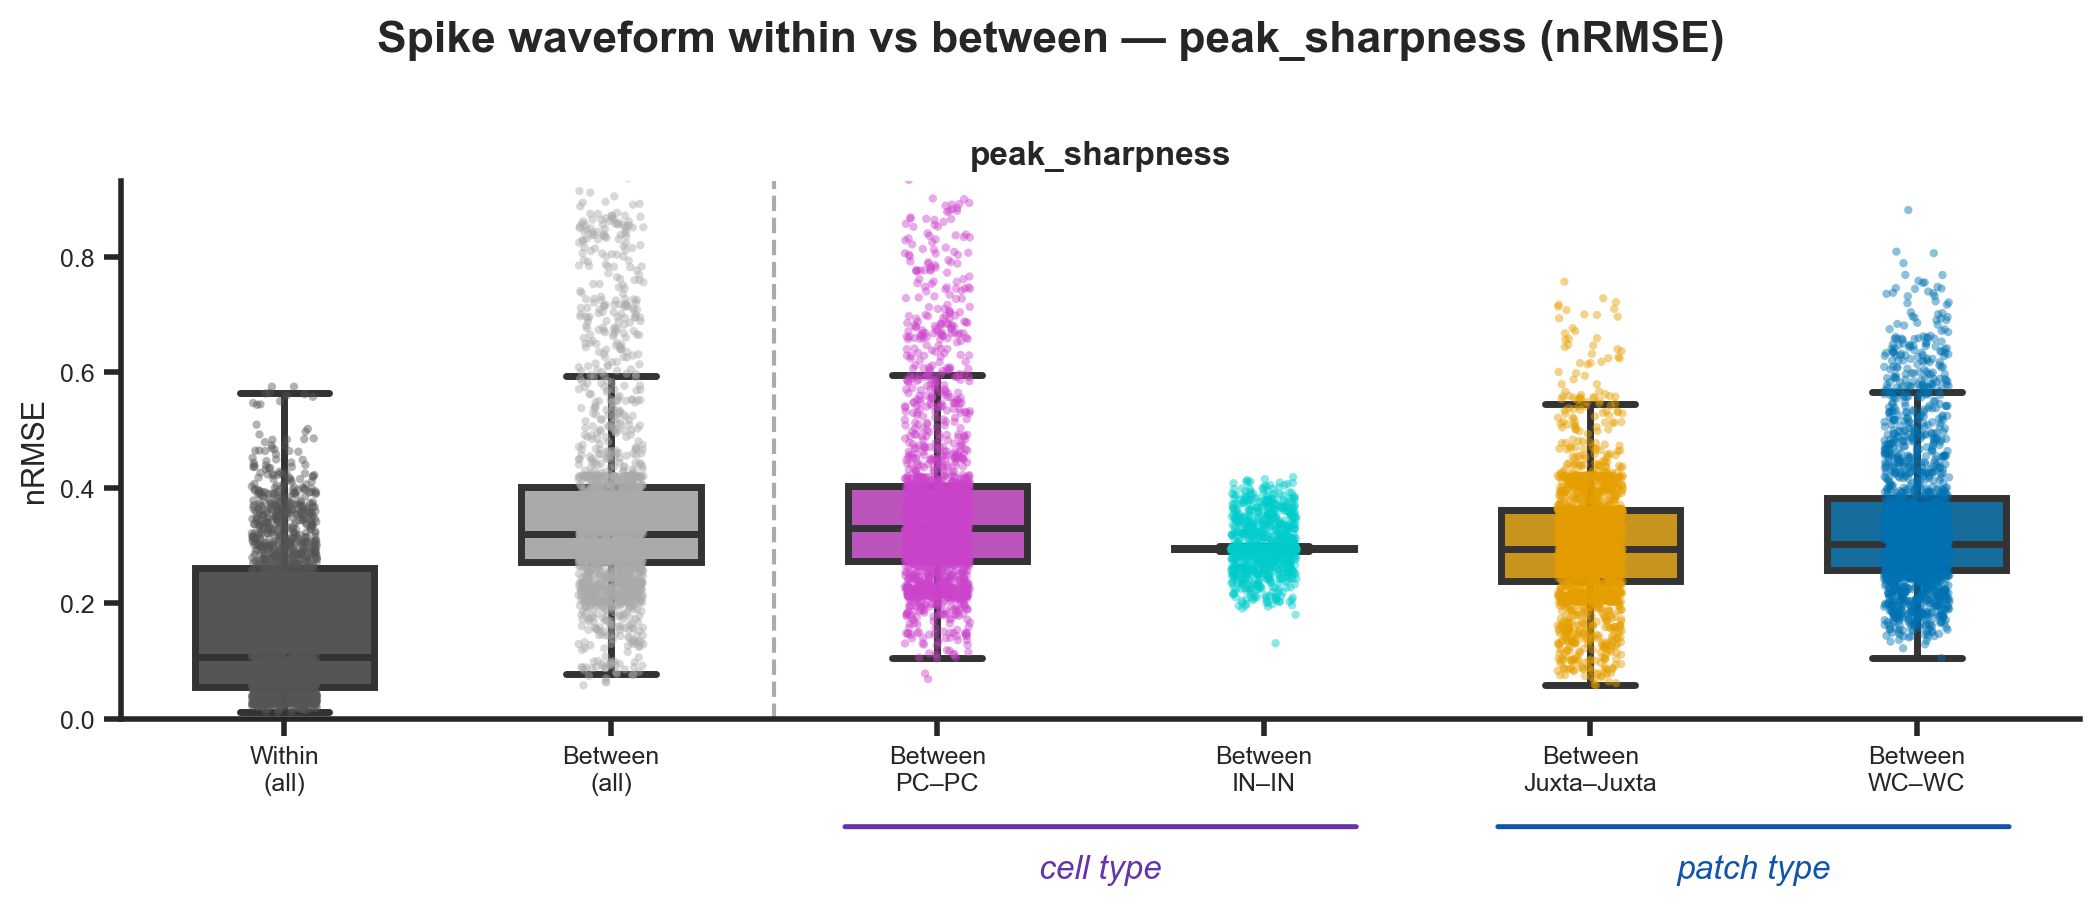

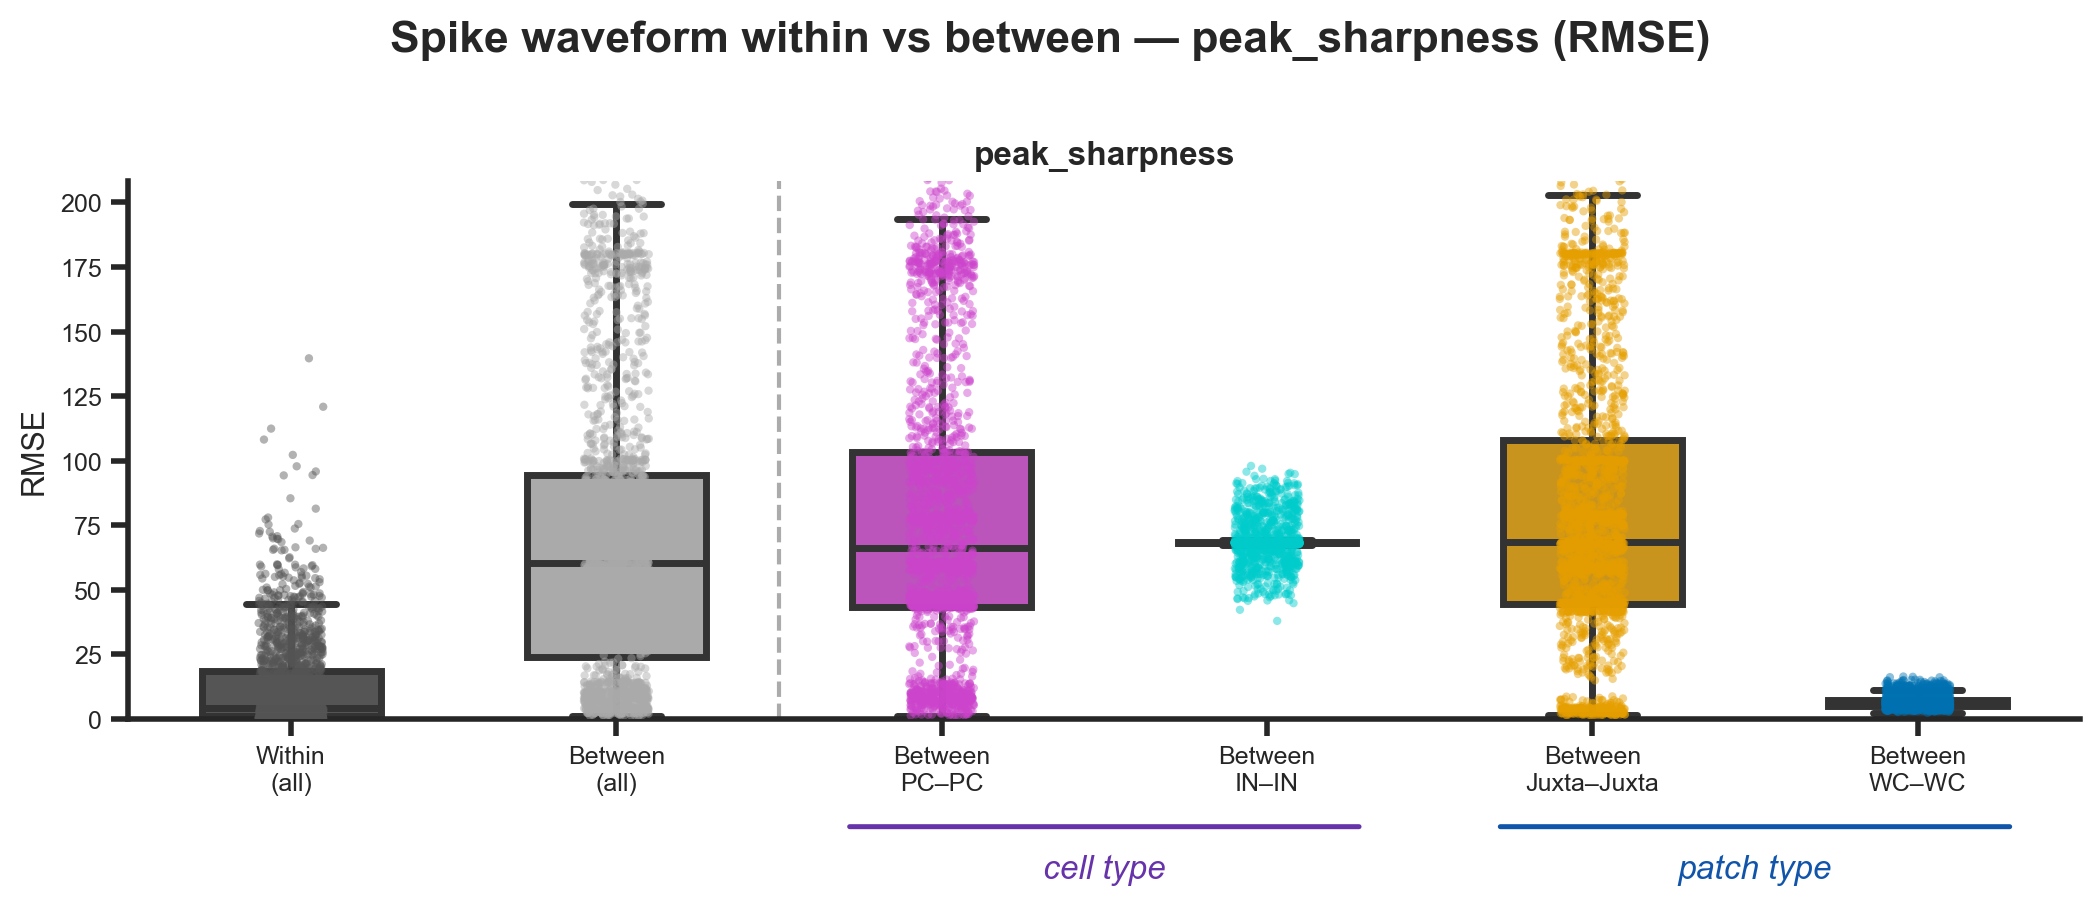

  peak_width: loaded from cache


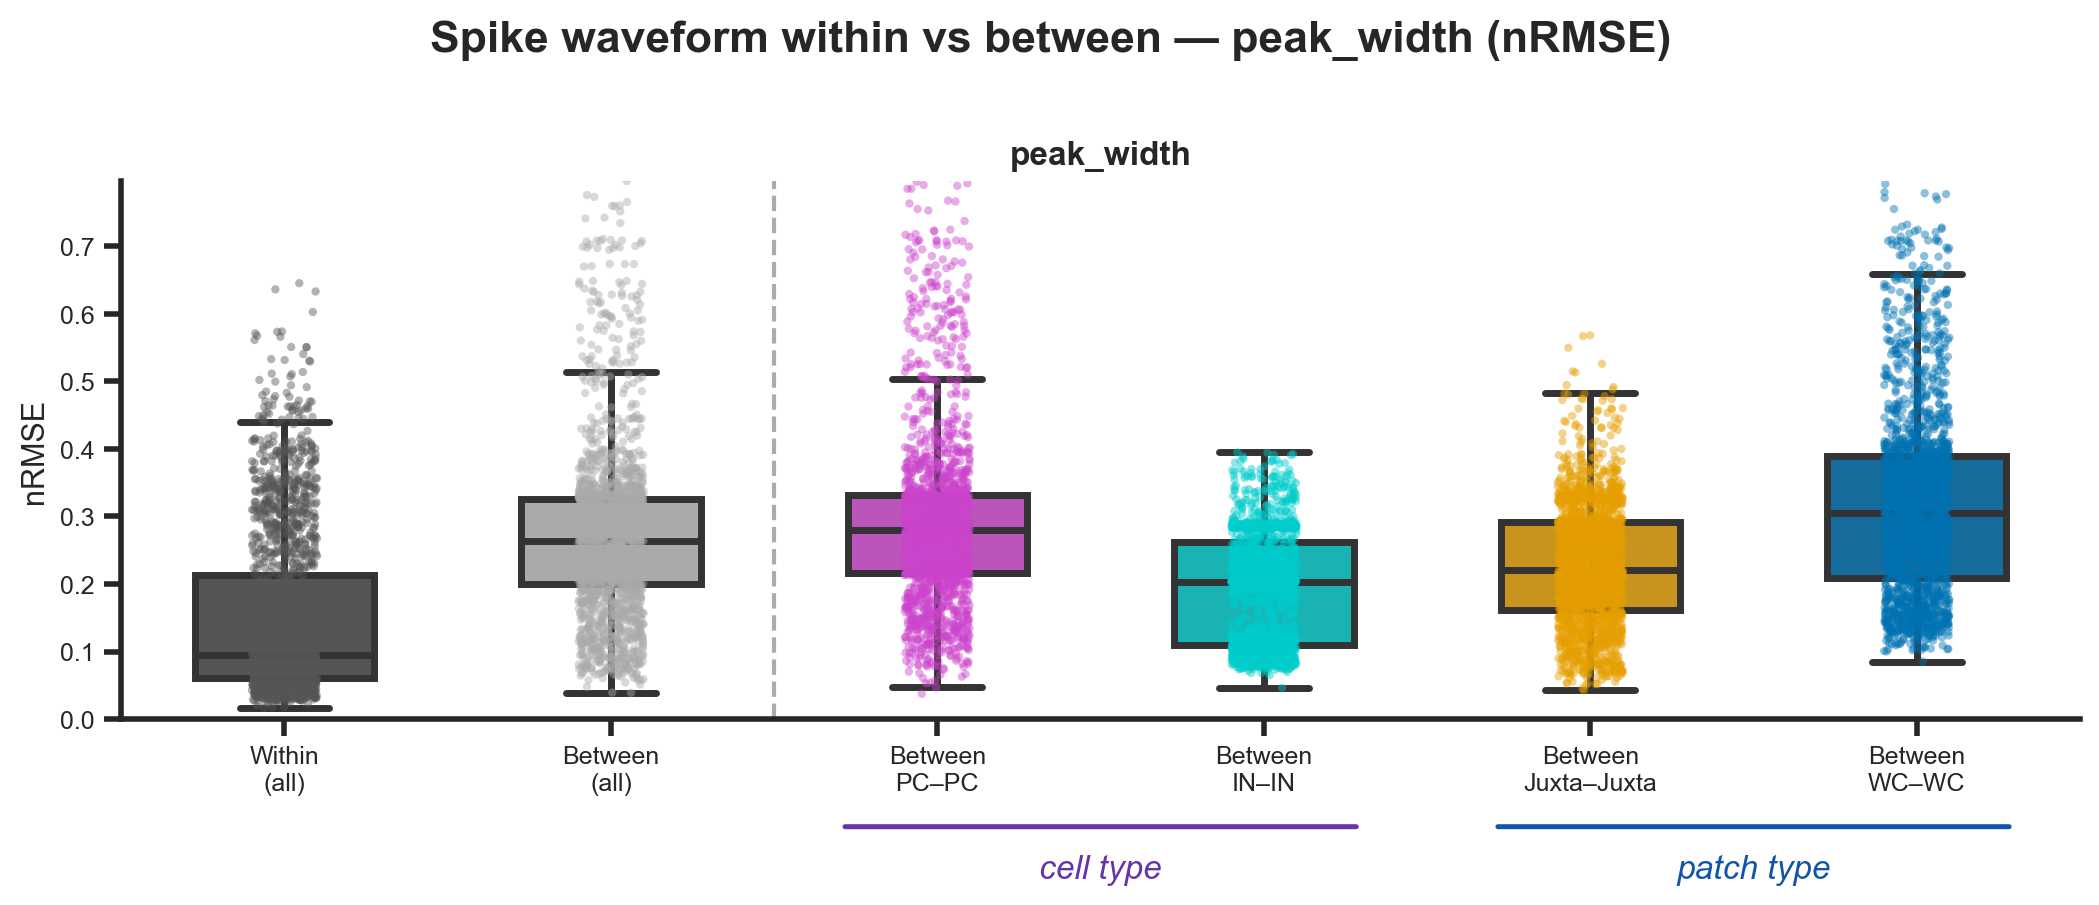

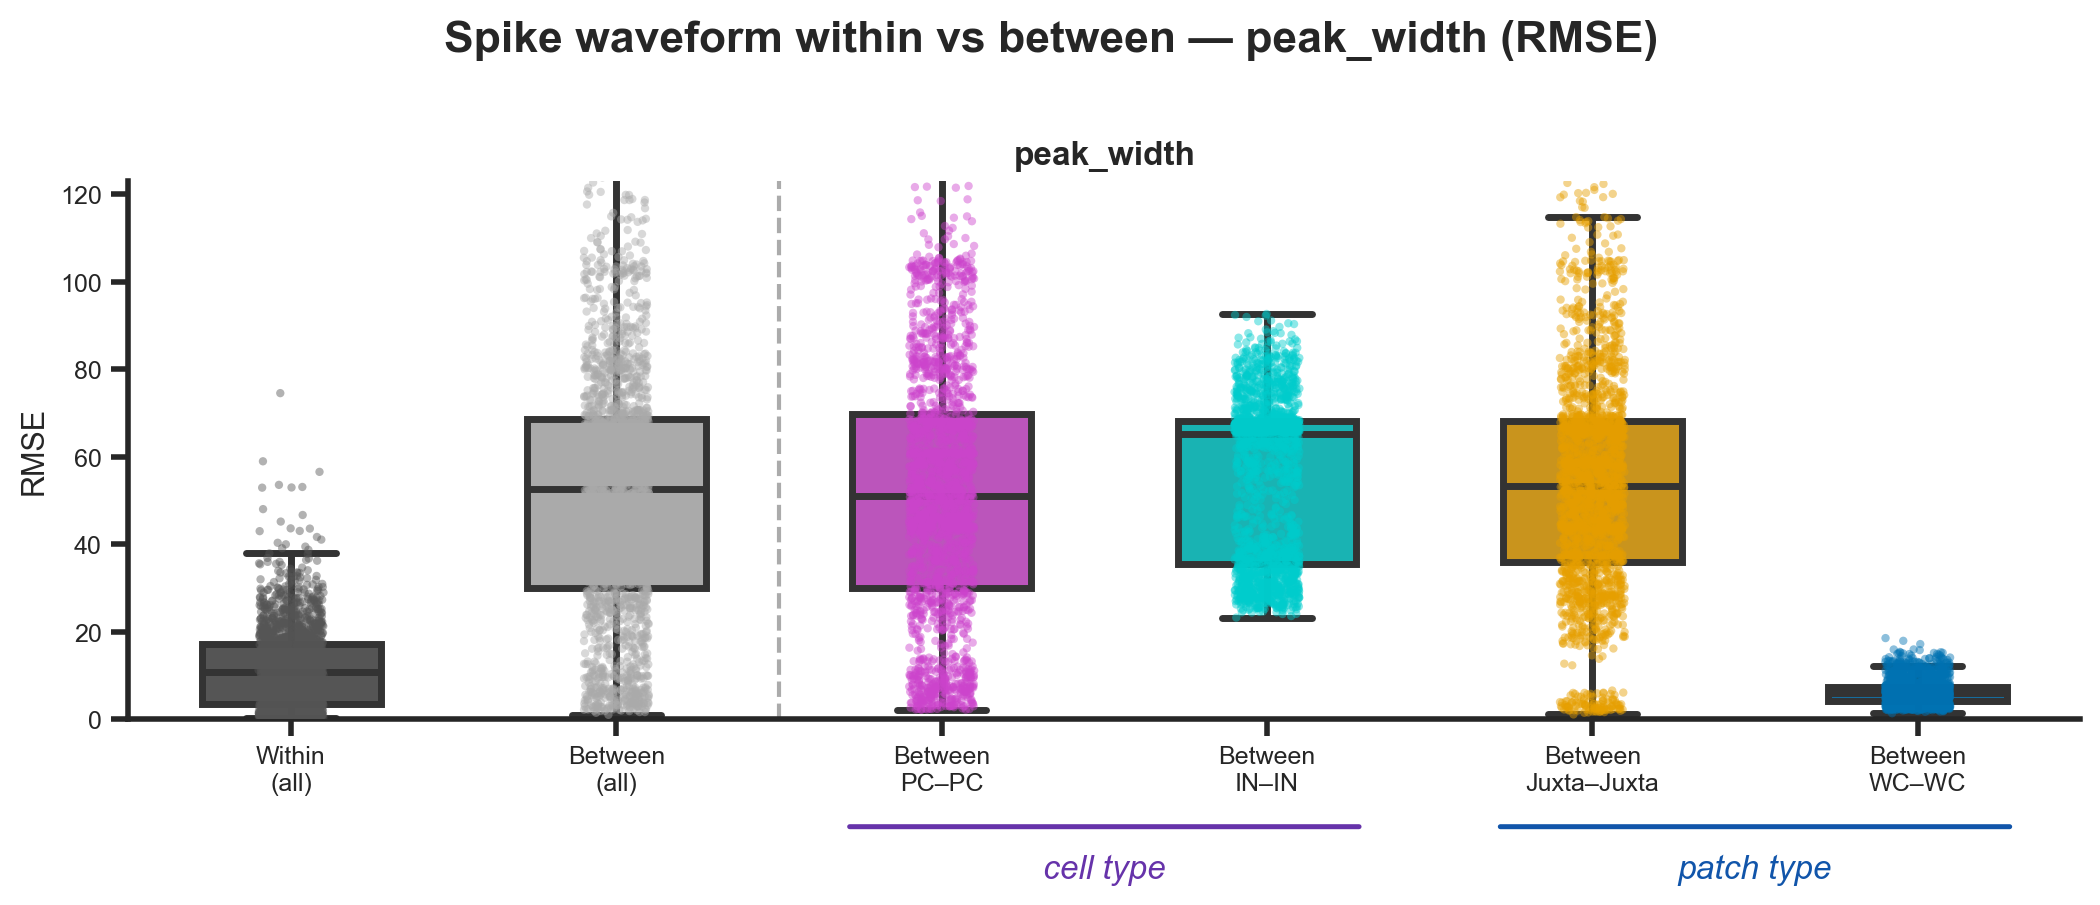

  exp_lambda: loaded from cache


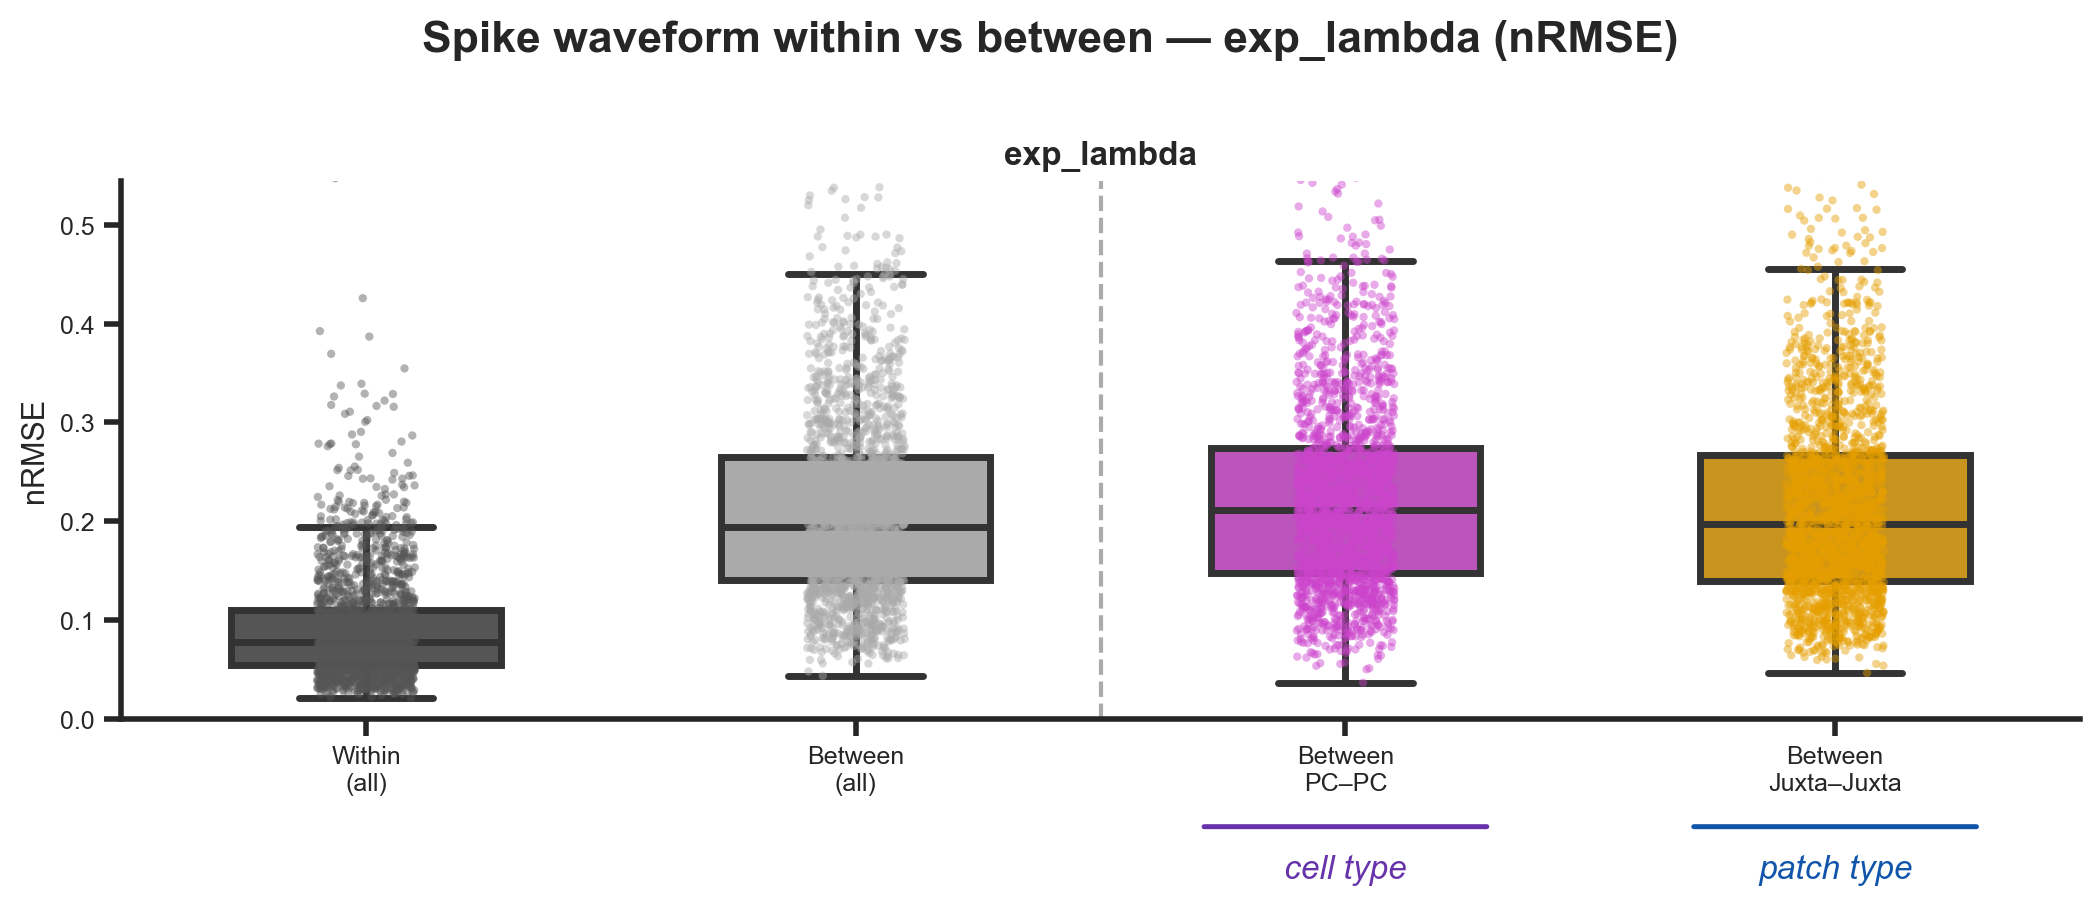

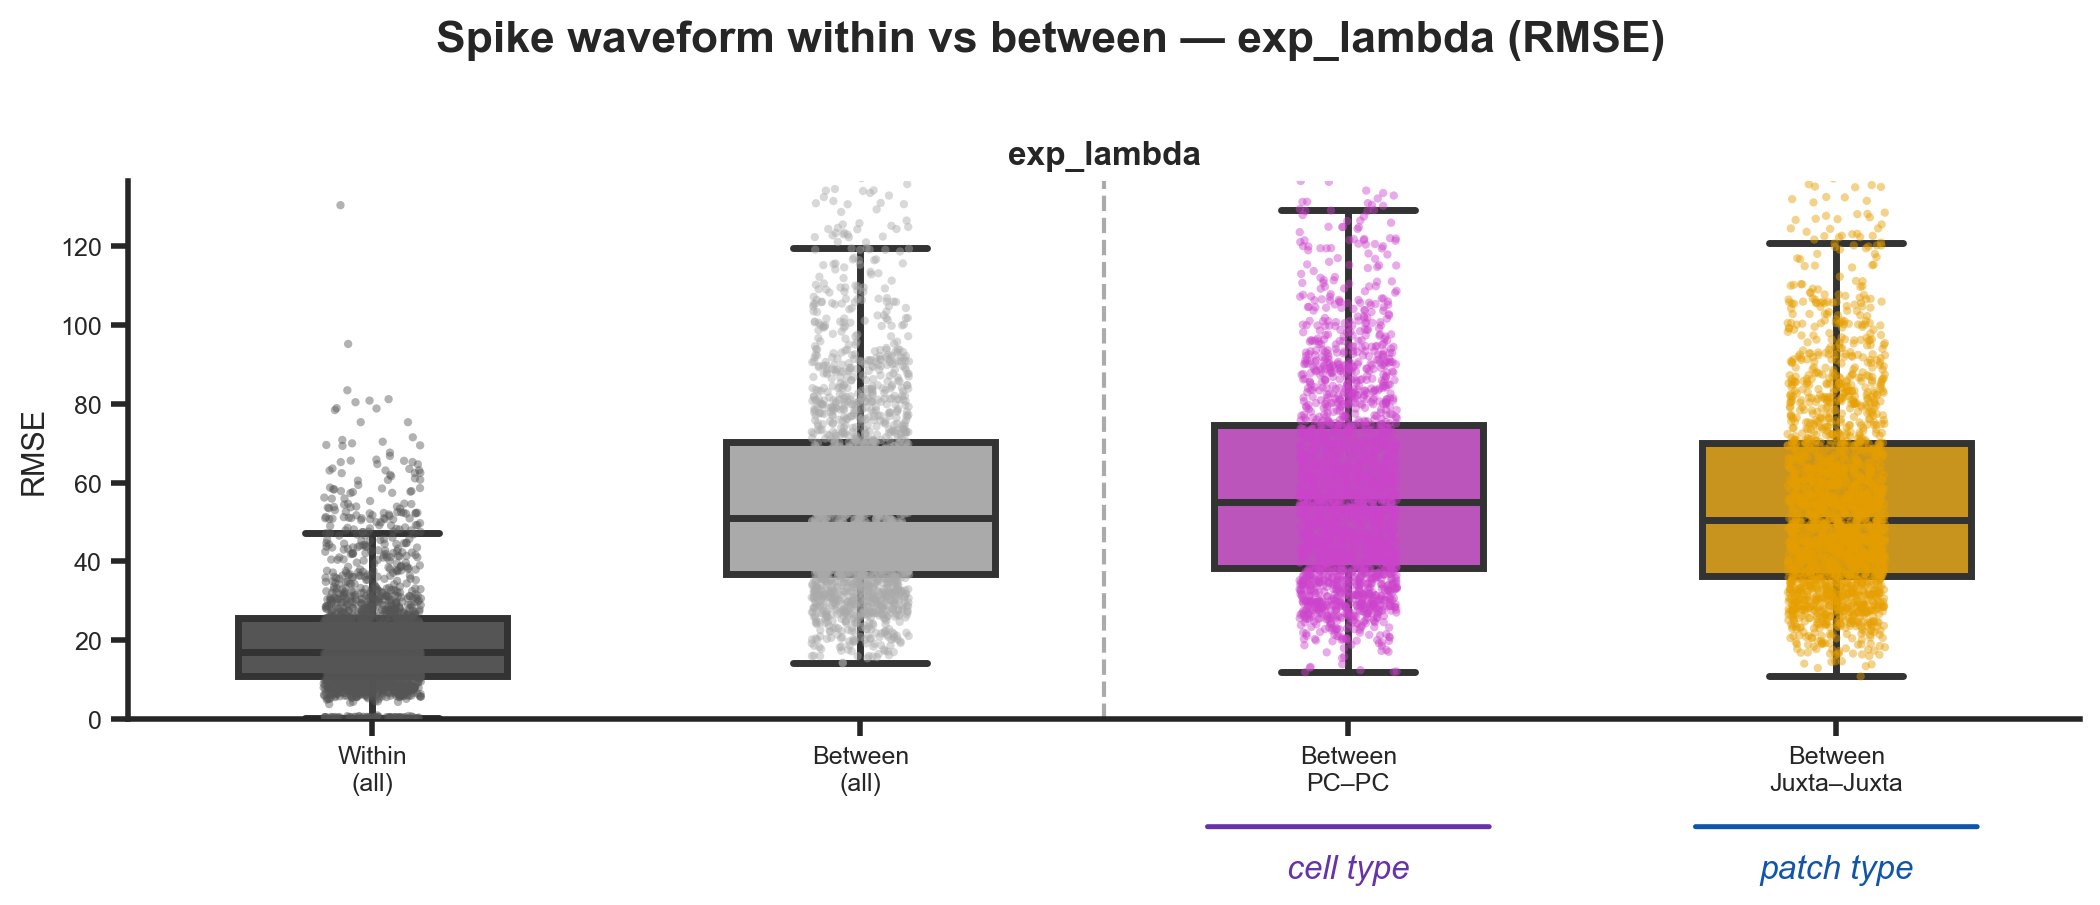

  inflection_amp: loaded from cache


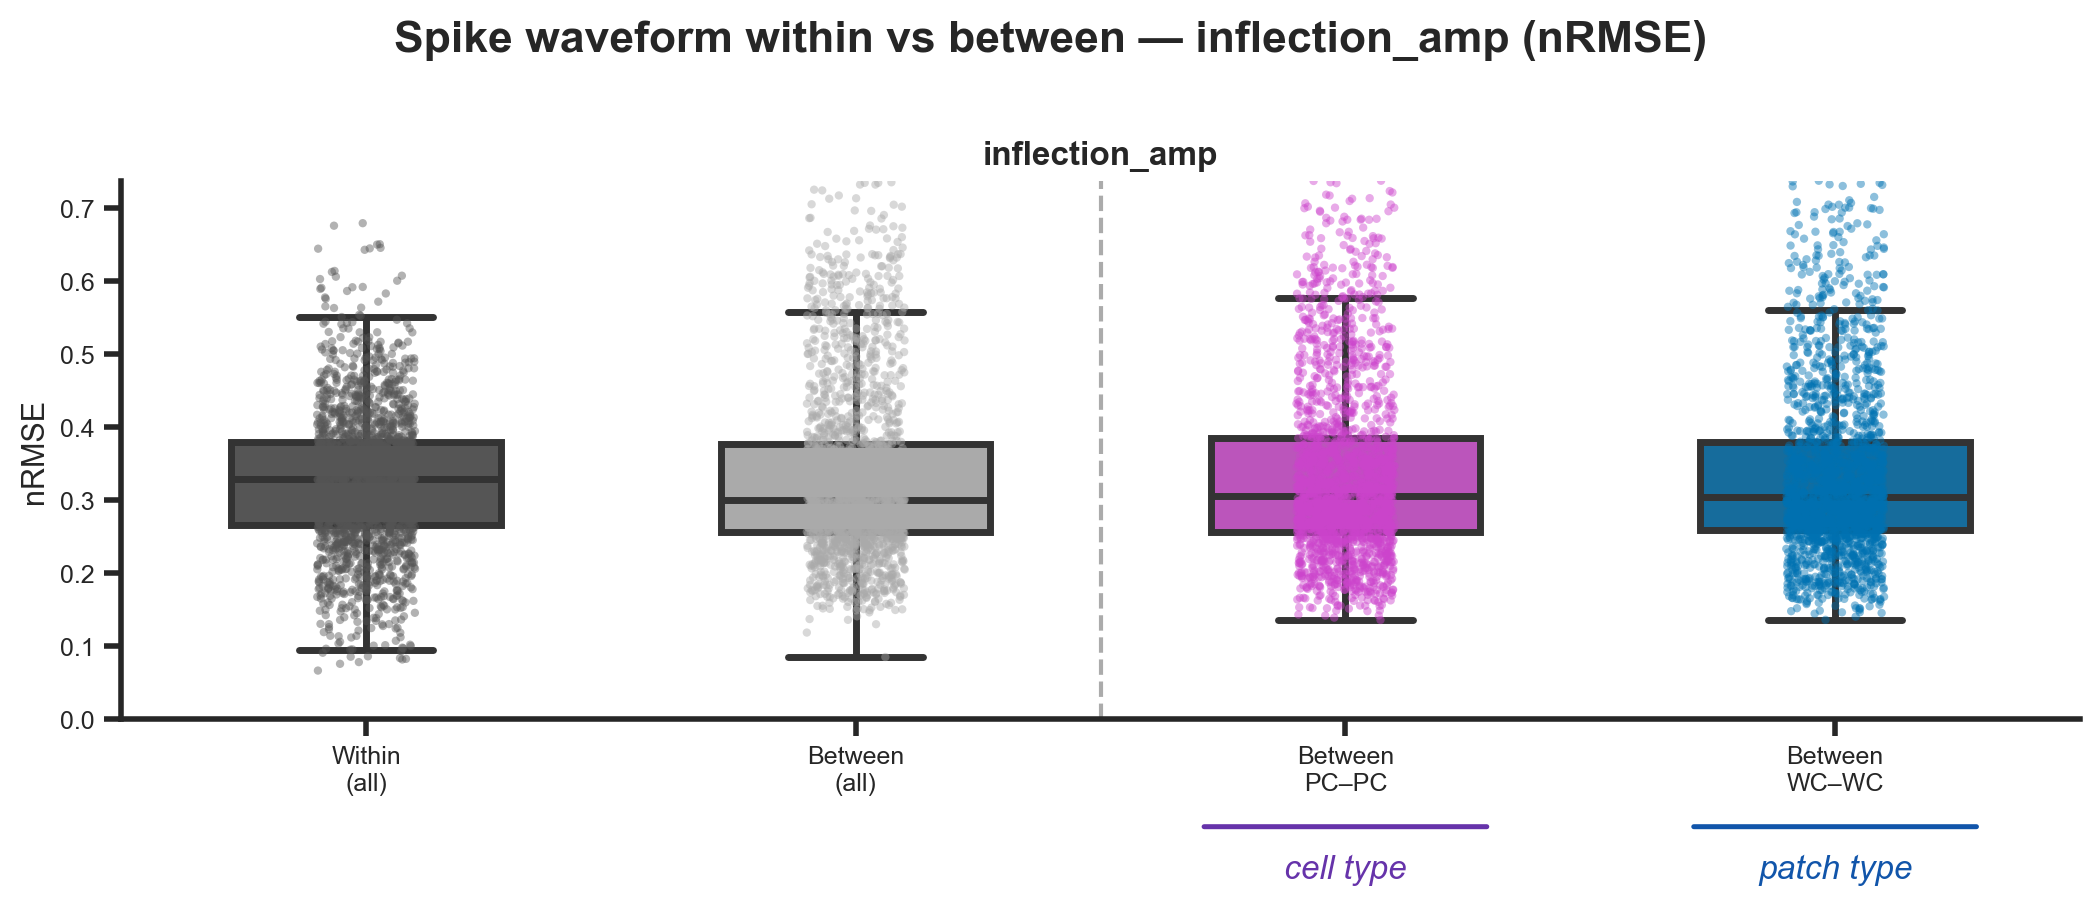

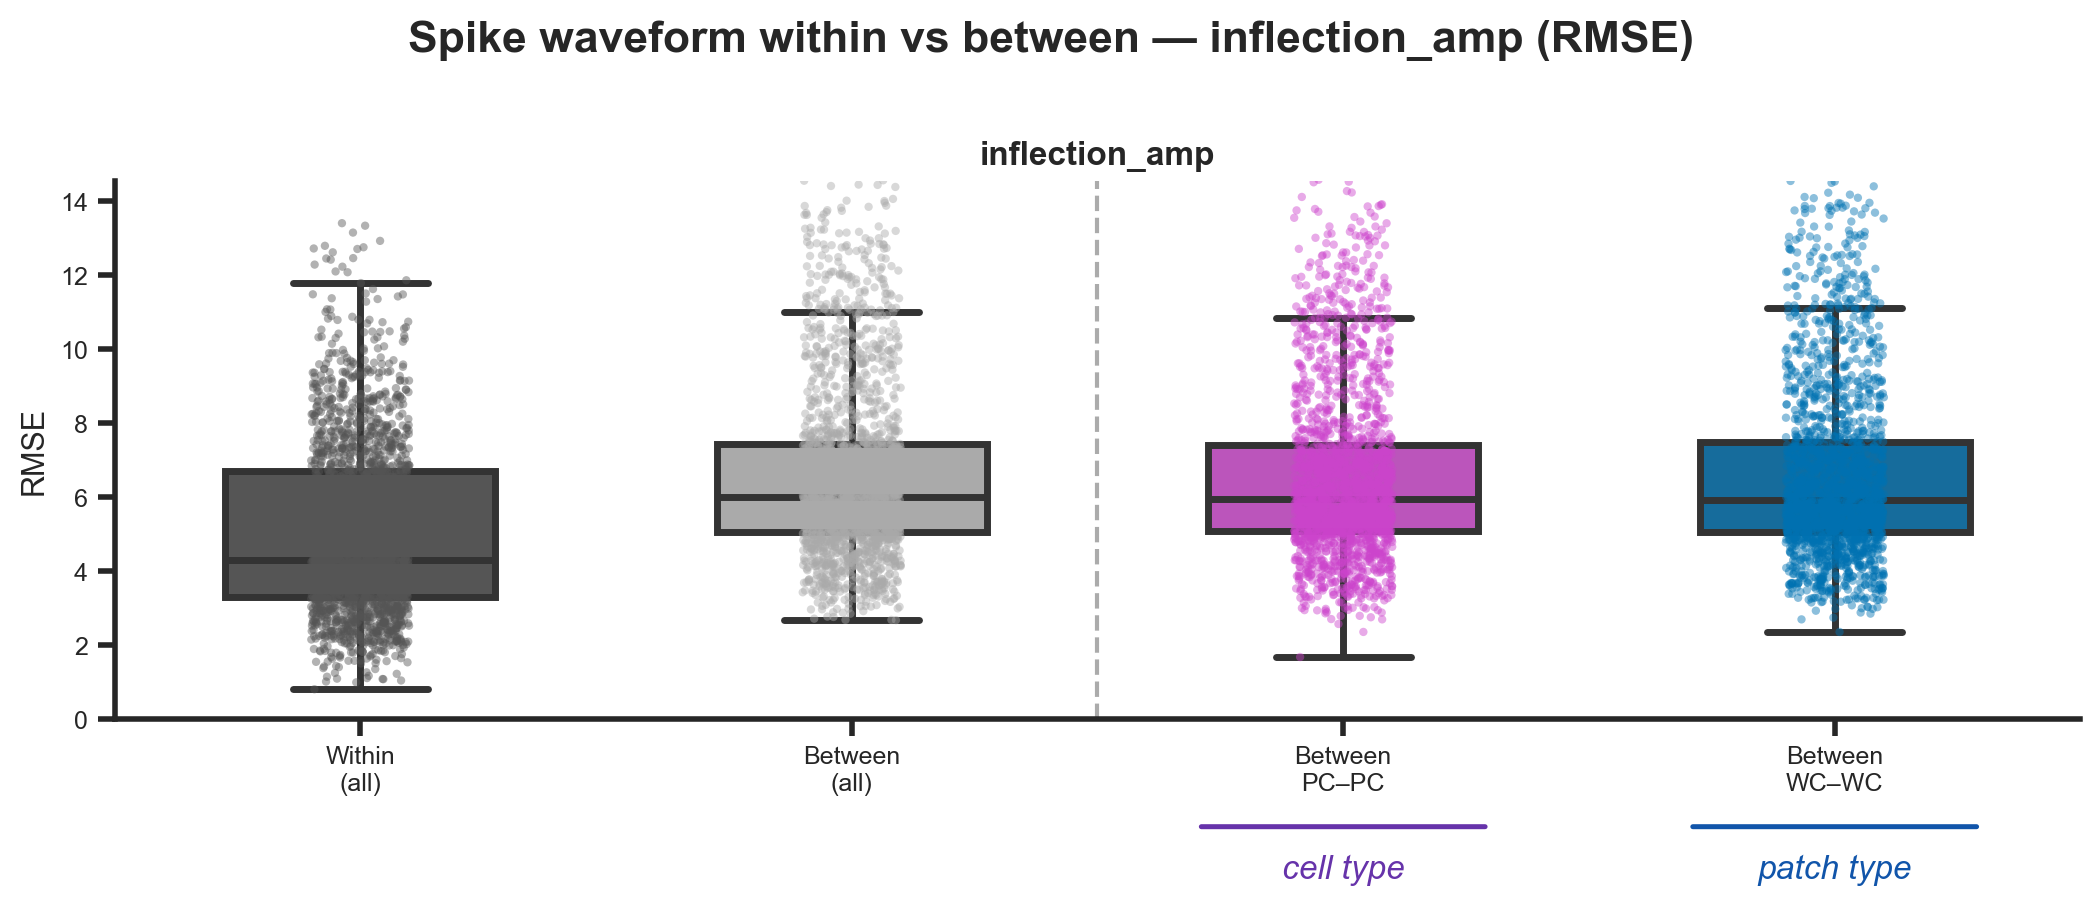

  inflection_time: loaded from cache


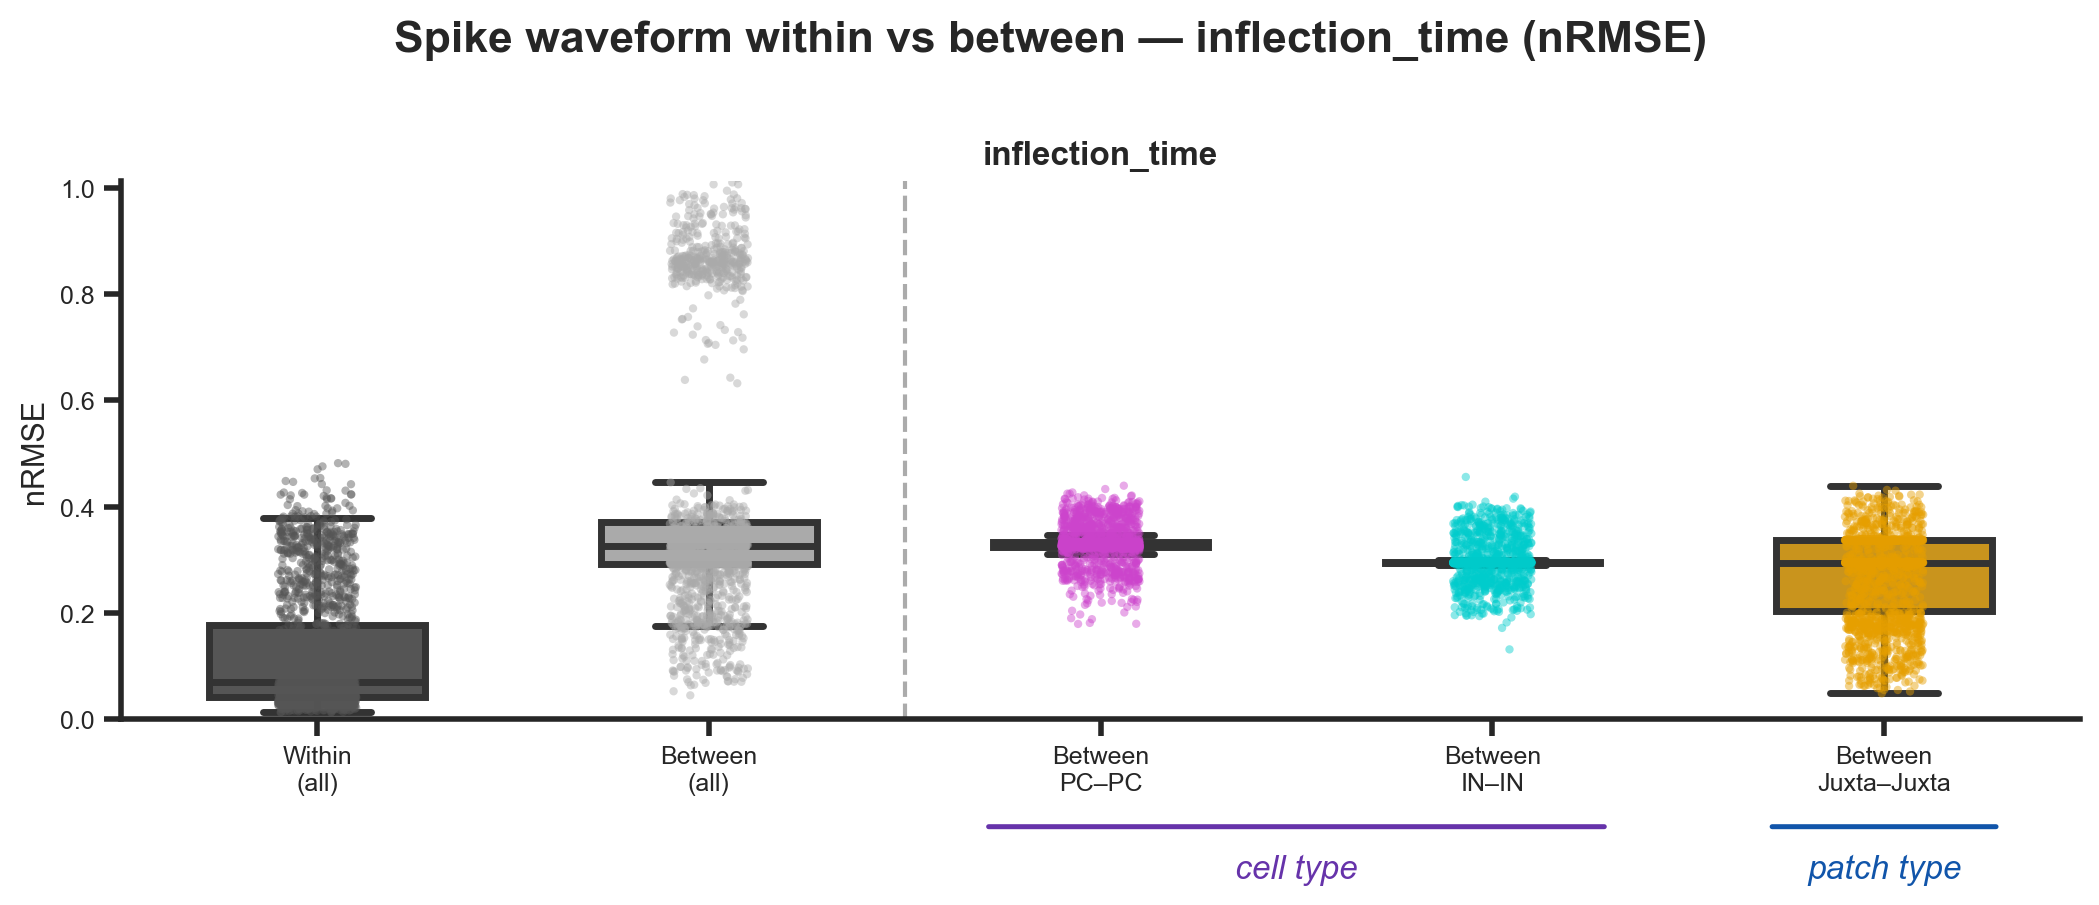

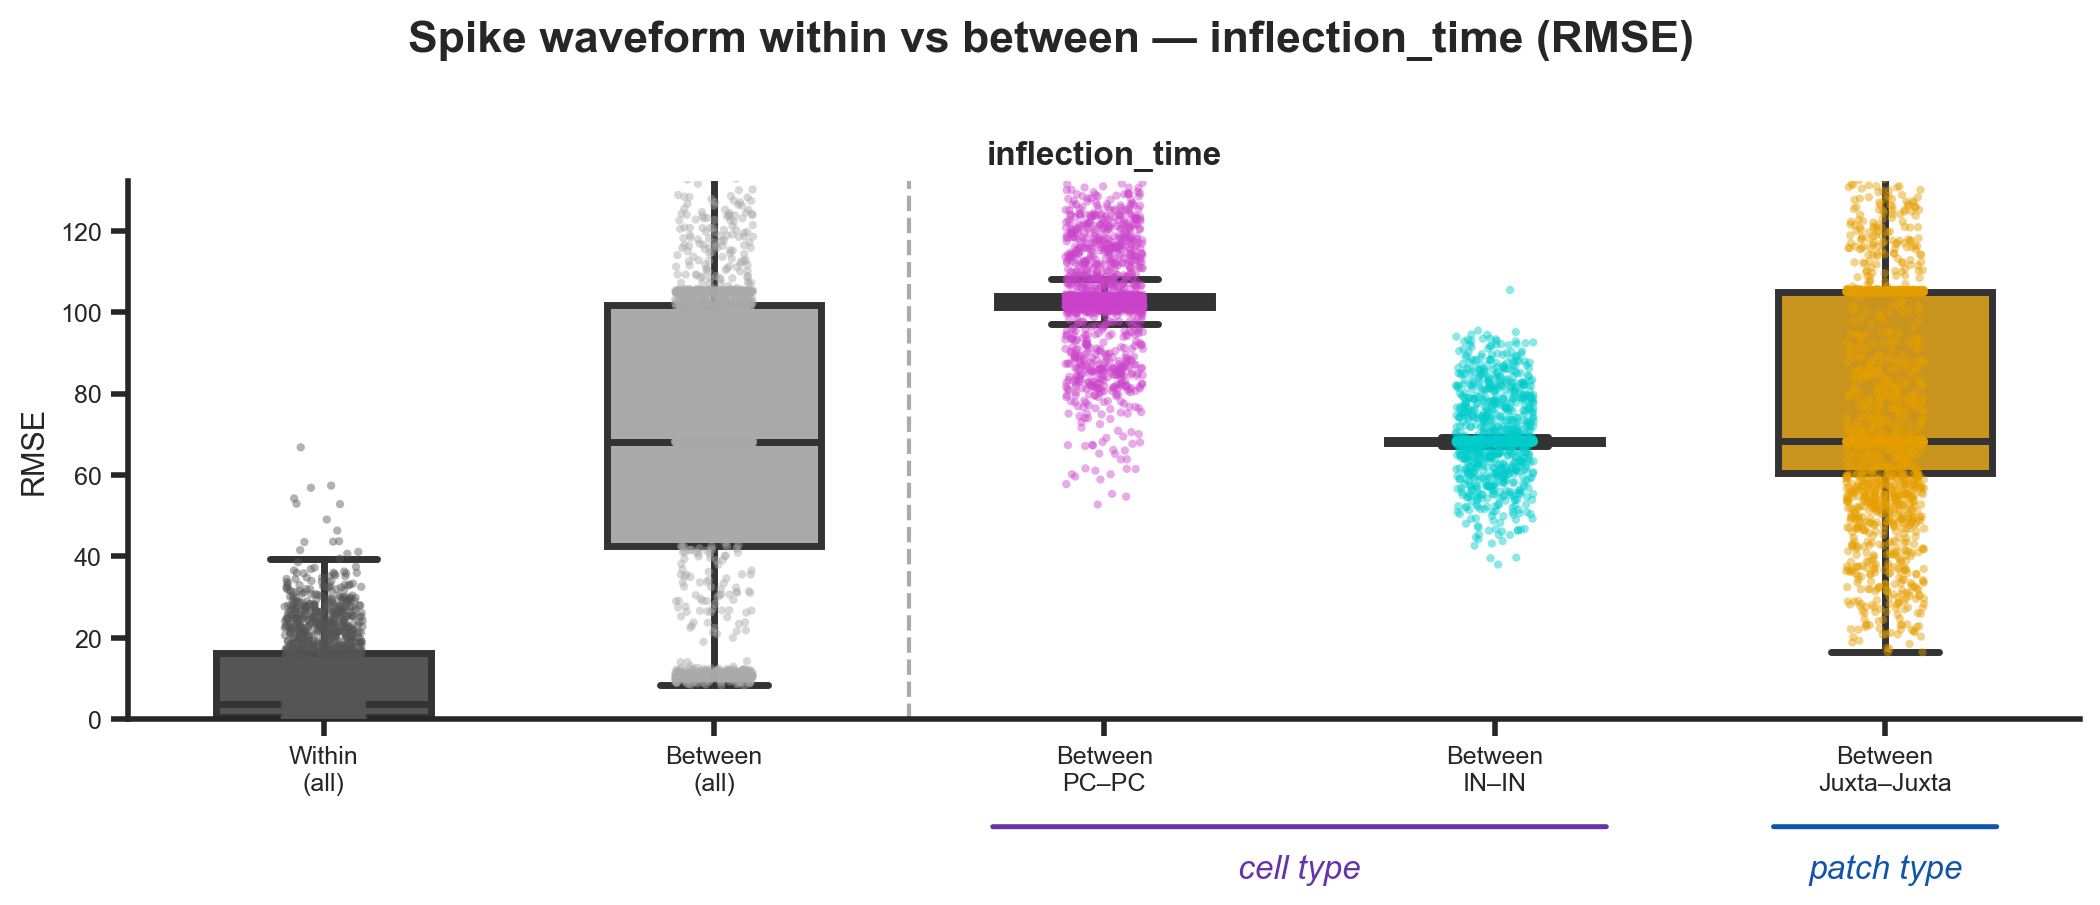

In [6]:
plot_spike_feature_within_vs_between(cluster_pickle_dir, spike_fit_dir, detailed=True, df_master=df_master)

Each spike is compared to the mean waveform of its own cell (within) and to the mean waveform of every other cell (between). Both distances are spike-to-average nRMSE/cos_sim, making the comparison scale-consistent. Within is ~167k spikes; between is ~7M comparisons across 38 cells.

[spike_to_avg] cache HIT — loading


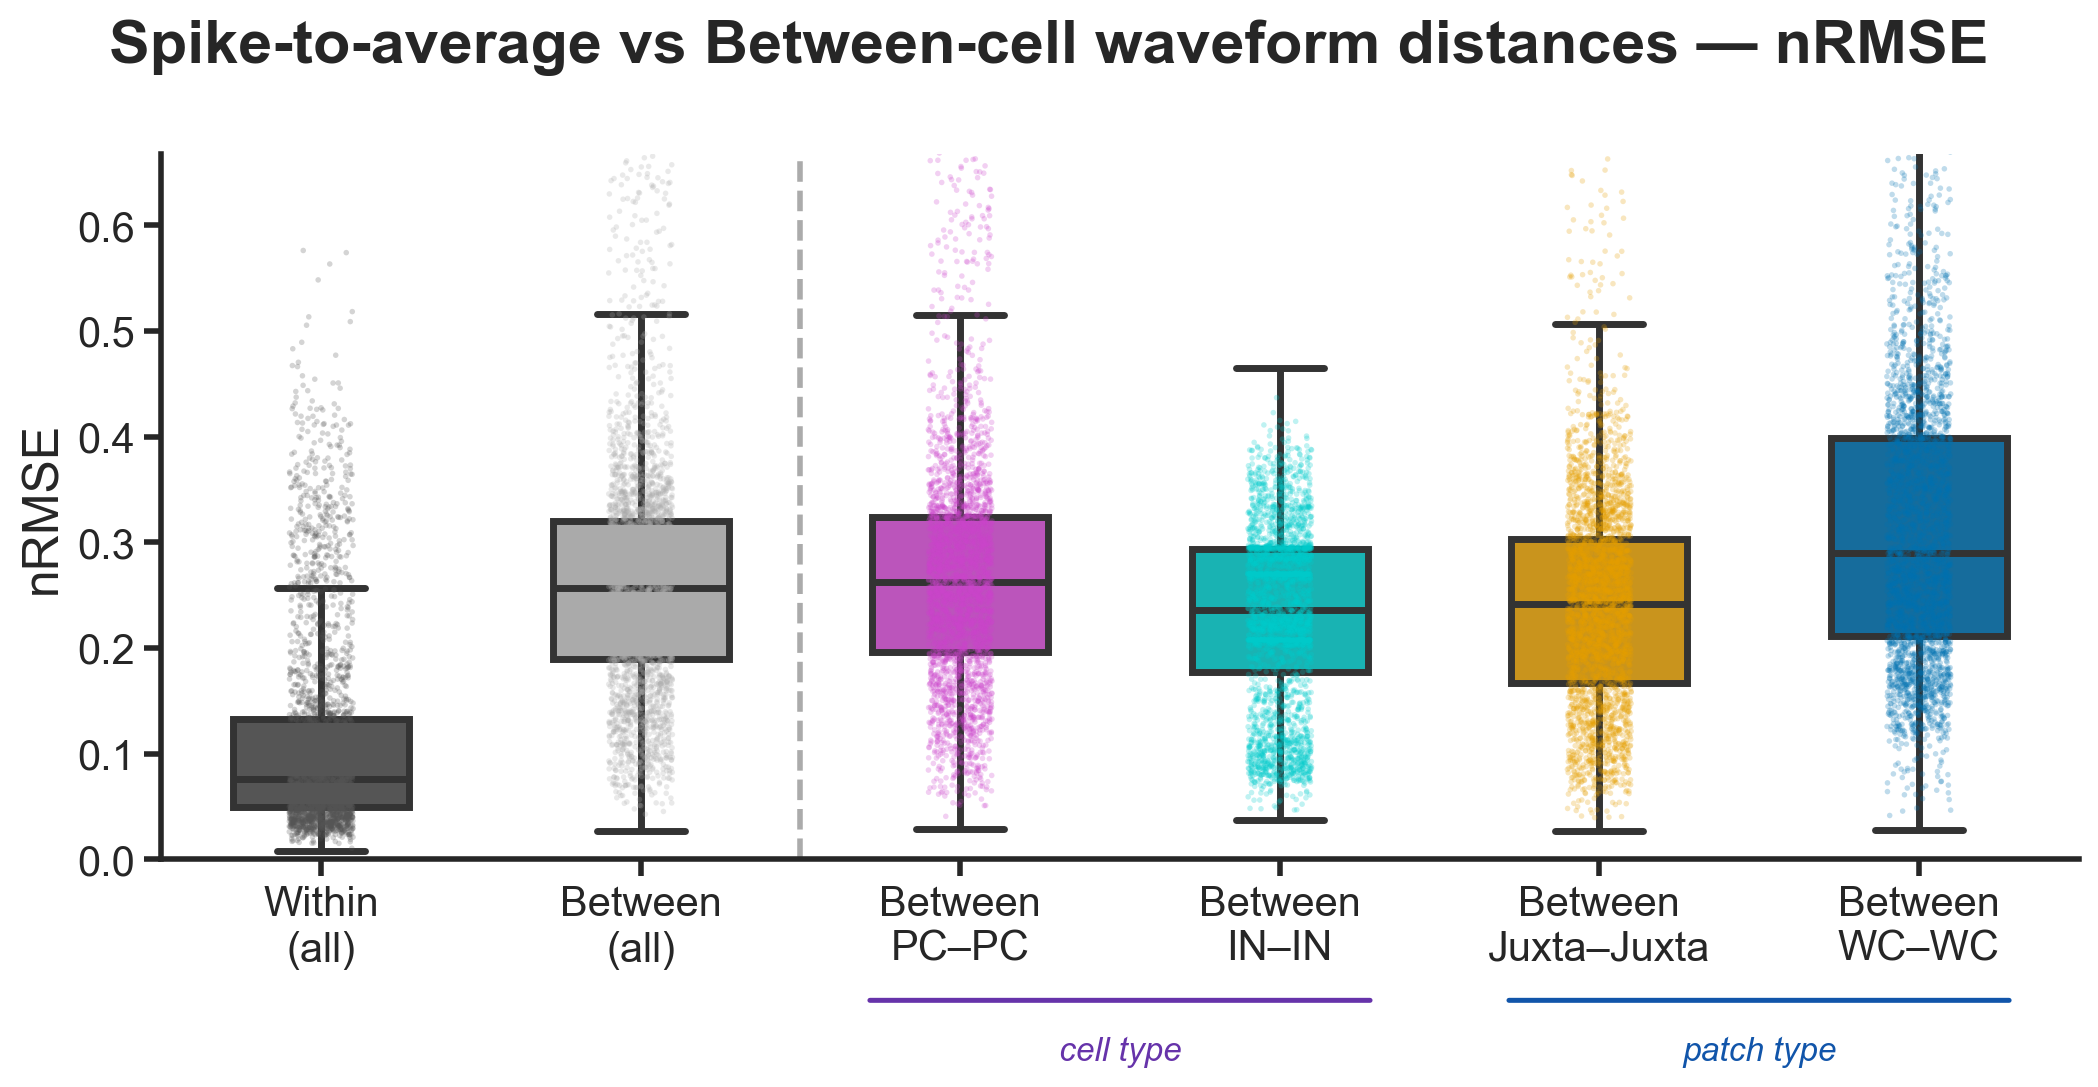


── nRMSE (spike-to-avg) ──
  Within (all)          : median=0.076  IQR=[0.050, 0.133]  n=167006
  Between (all)         : median=0.257  IQR=[0.189, 0.320]  n=200000
  Between PC–PC         : median=0.263  IQR=[0.197, 0.324]  n=200000
  Between IN–IN         : median=0.236  IQR=[0.178, 0.294]  n=200000
  Between Juxta–Juxta   : median=0.241  IQR=[0.167, 0.303]  n=200000
  Between WC–WC         : median=0.290  IQR=[0.211, 0.399]  n=77752


In [7]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    spike_fit_dir=spike_fit_dir,
    half_win=75,
    metrics=["nRMSE"],
)

[spike_to_avg] cache HIT — loading


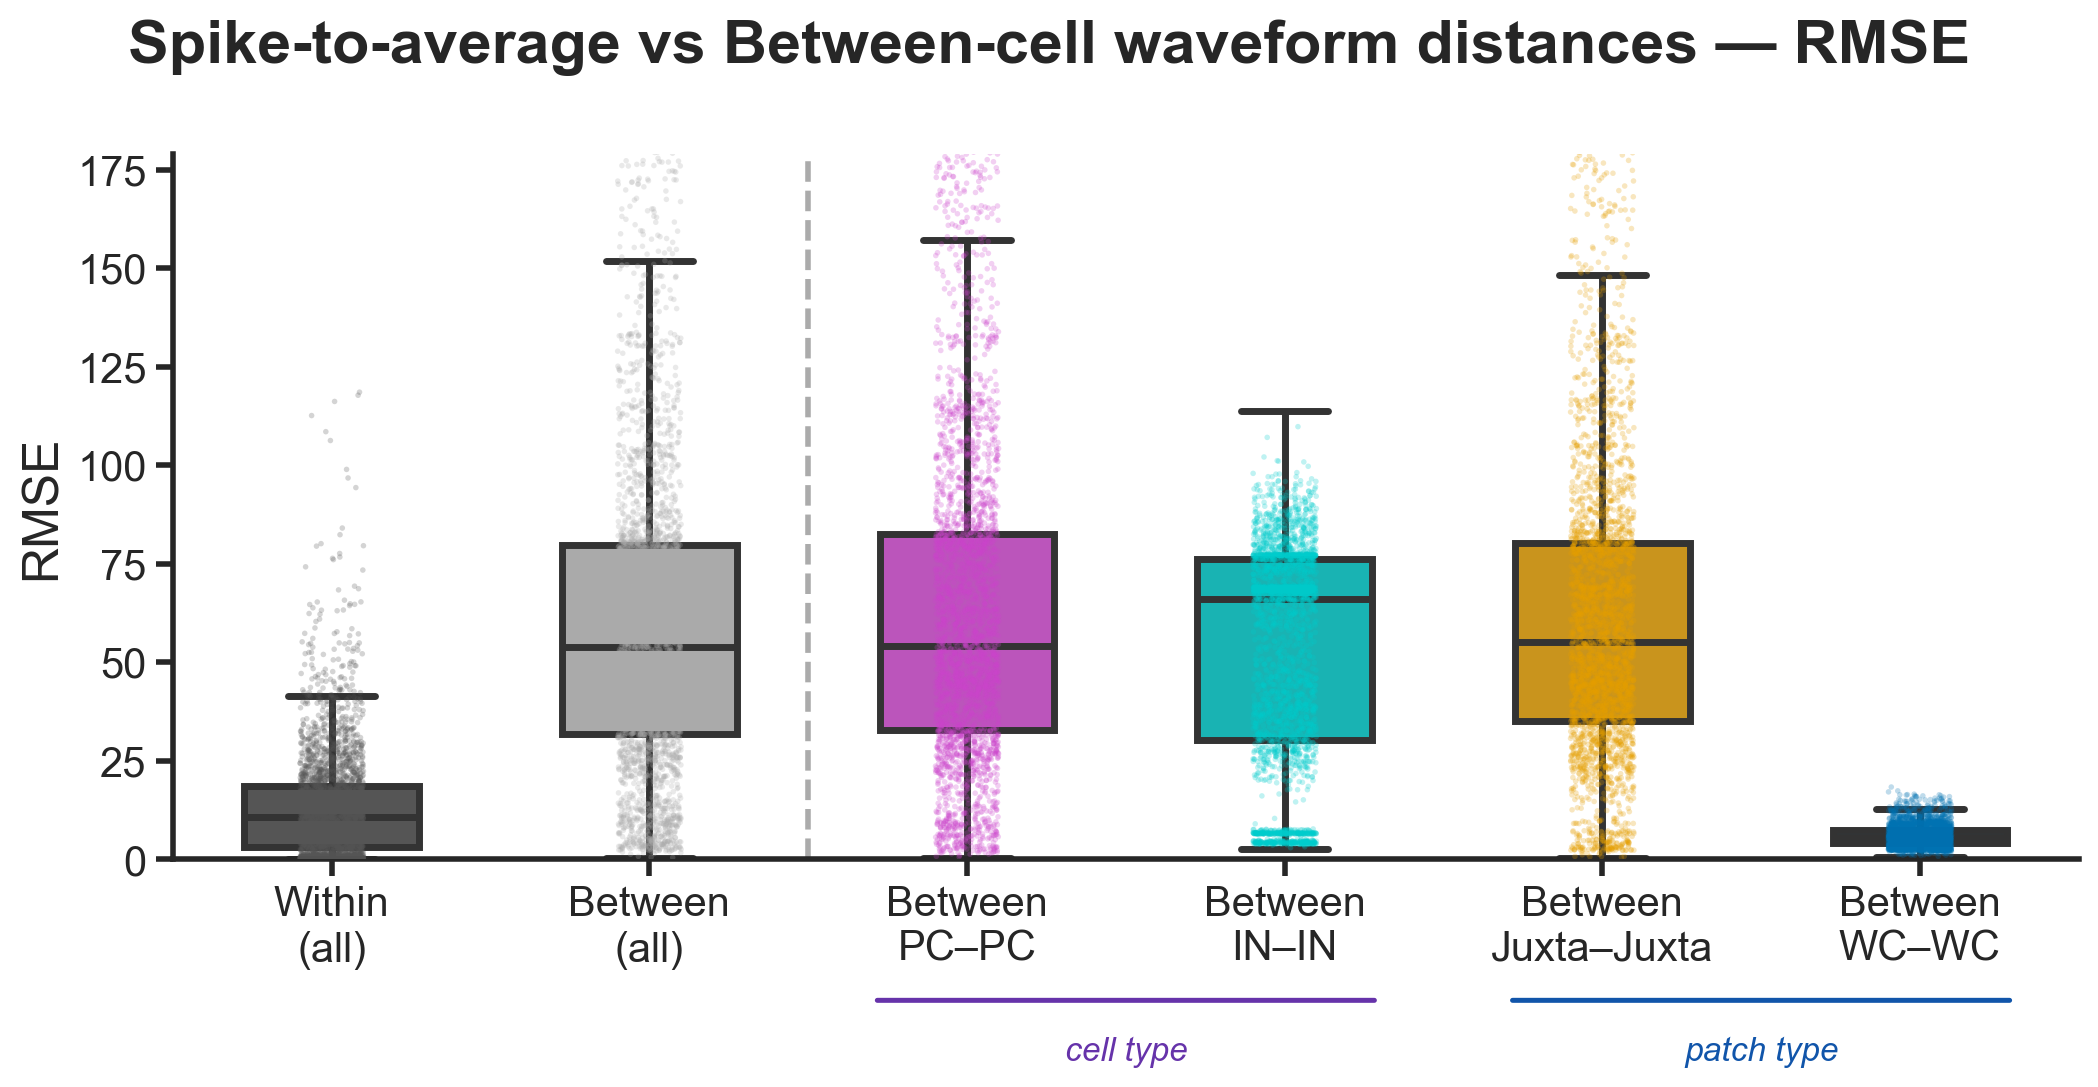


── RMSE (spike-to-avg) ──
  Within (all)          : median=10.807  IQR=[3.193, 18.527]  n=167006
  Between (all)         : median=53.757  IQR=[31.881, 79.829]  n=200000
  Between PC–PC         : median=54.194  IQR=[32.900, 82.664]  n=200000
  Between IN–IN         : median=65.950  IQR=[30.395, 76.129]  n=200000
  Between Juxta–Juxta   : median=55.177  IQR=[35.058, 80.324]  n=200000
  Between WC–WC         : median=5.766  IQR=[4.041, 7.521]  n=77752


In [8]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    spike_fit_dir=spike_fit_dir,
    half_win=75,
    metrics=["RMSE"],
)

[spike_to_avg] cache HIT — loading


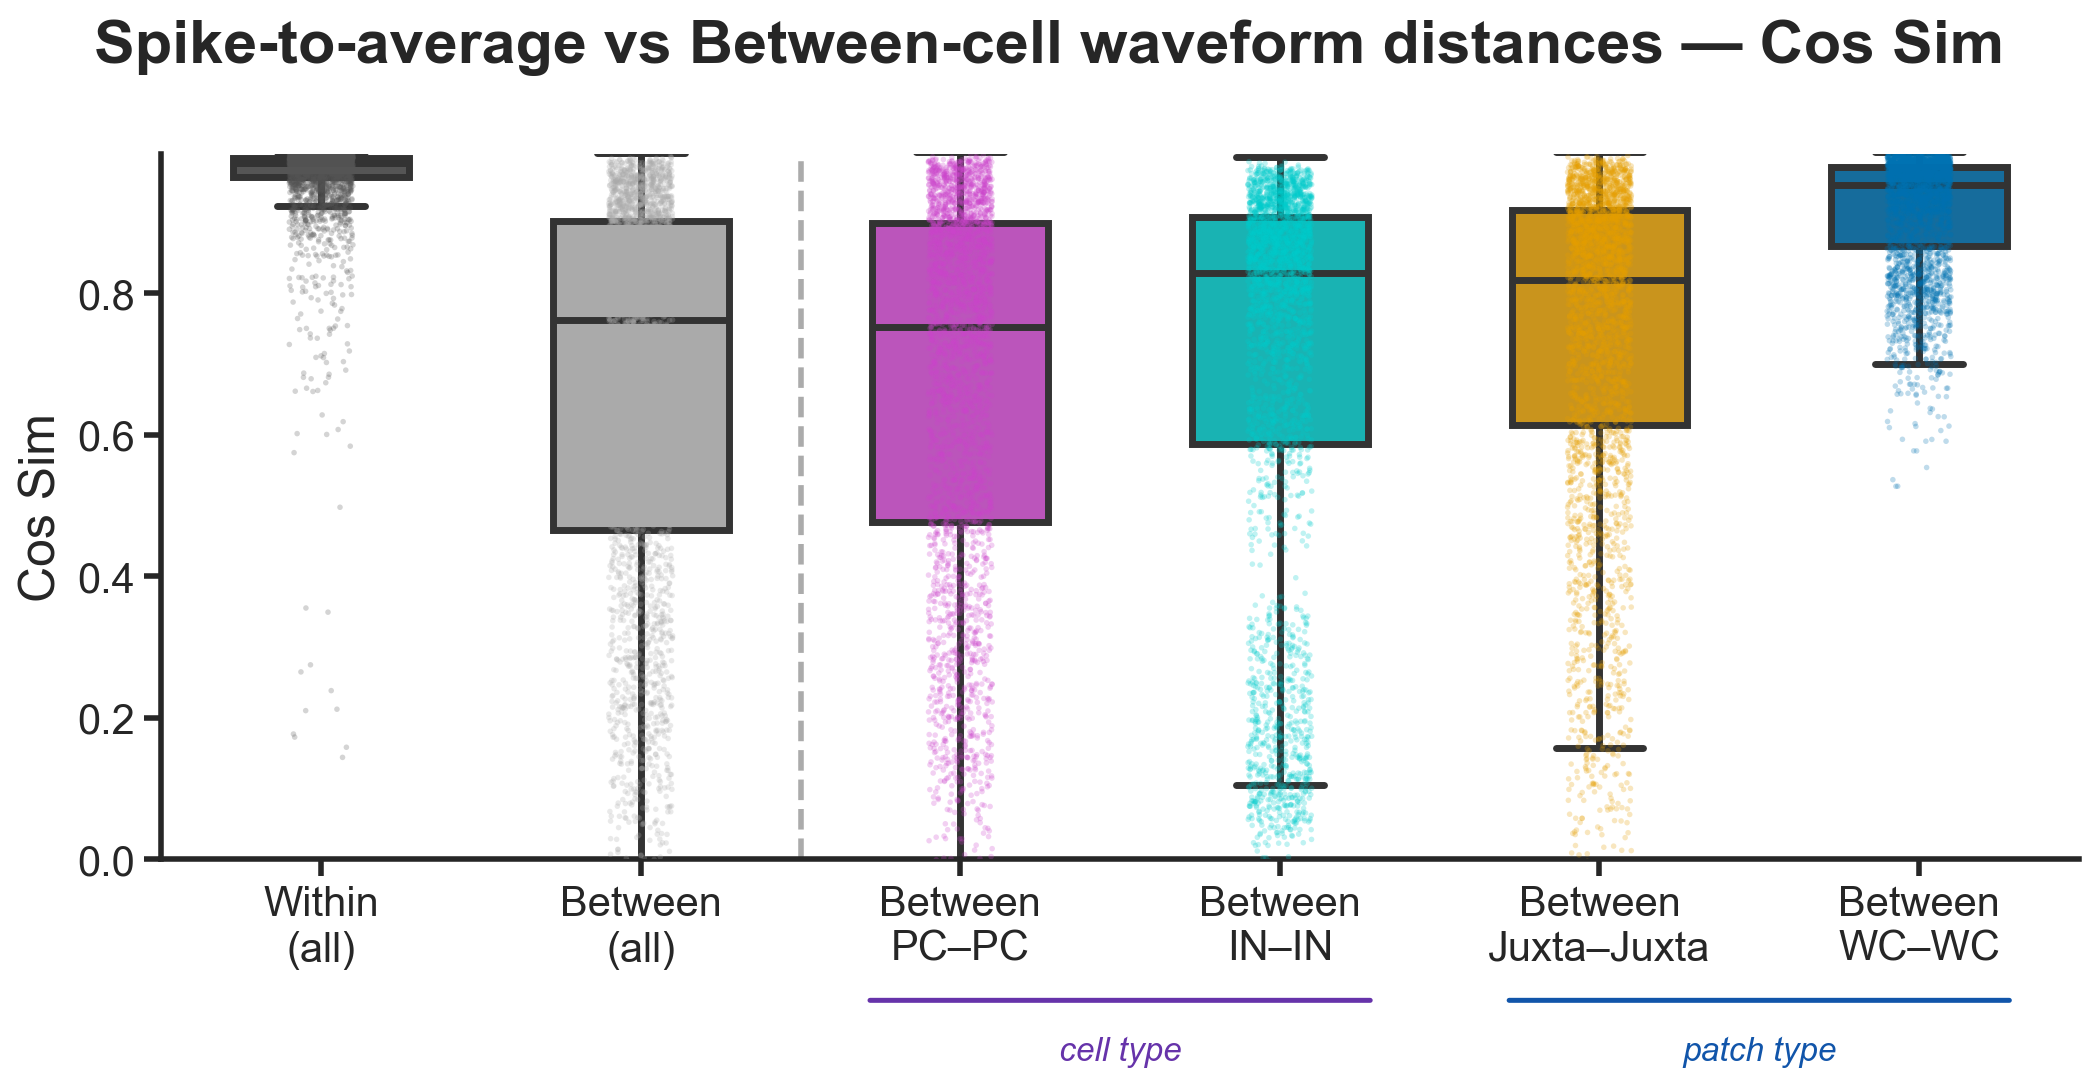


── Cos Sim (spike-to-avg) ──
  Within (all)          : median=0.984  IQR=[0.965, 0.992]  n=167006
  Between (all)         : median=0.762  IQR=[0.465, 0.903]  n=200000
  Between PC–PC         : median=0.752  IQR=[0.477, 0.900]  n=200000
  Between IN–IN         : median=0.828  IQR=[0.587, 0.908]  n=200000
  Between Juxta–Juxta   : median=0.819  IQR=[0.614, 0.918]  n=200000
  Between WC–WC         : median=0.953  IQR=[0.868, 0.979]  n=77752


In [9]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    spike_fit_dir=spike_fit_dir,
    half_win=75,
    metrics=["Cos Sim"],
)

## Visualization options: within vs between per cell
Three candidate views. Option 1: full-spike KDE. Option 2: per-cell scatter (unit = cell). Option 3: per-cell raincloud.

[sorted_dots] cache HIT


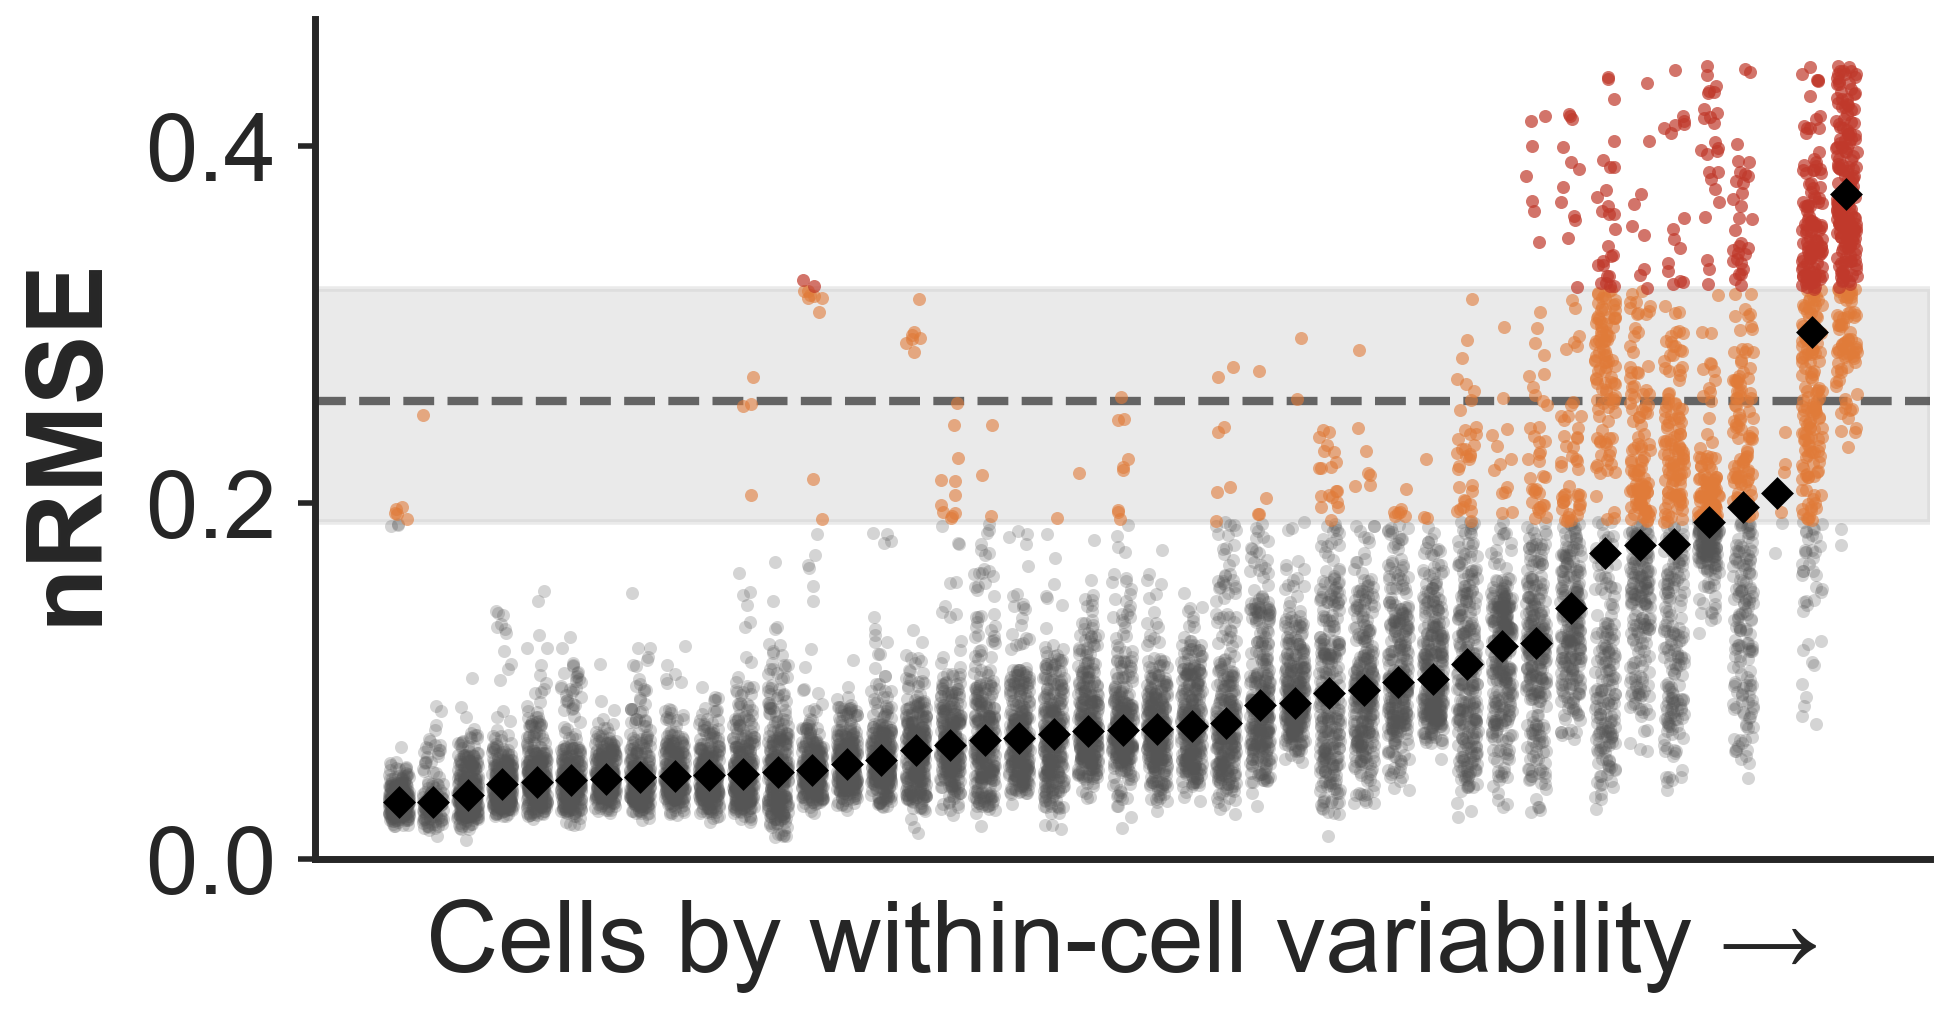

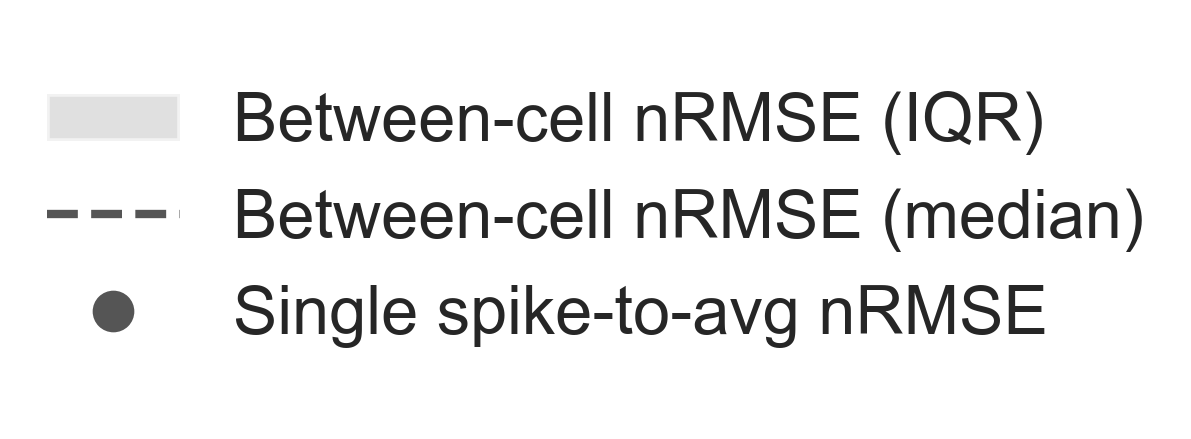

In [10]:
plot_waveform_dist_sorted_dots(df_master, wf_dir=cluster_pickle_dir, spike_fit_dir=spike_fit_dir)

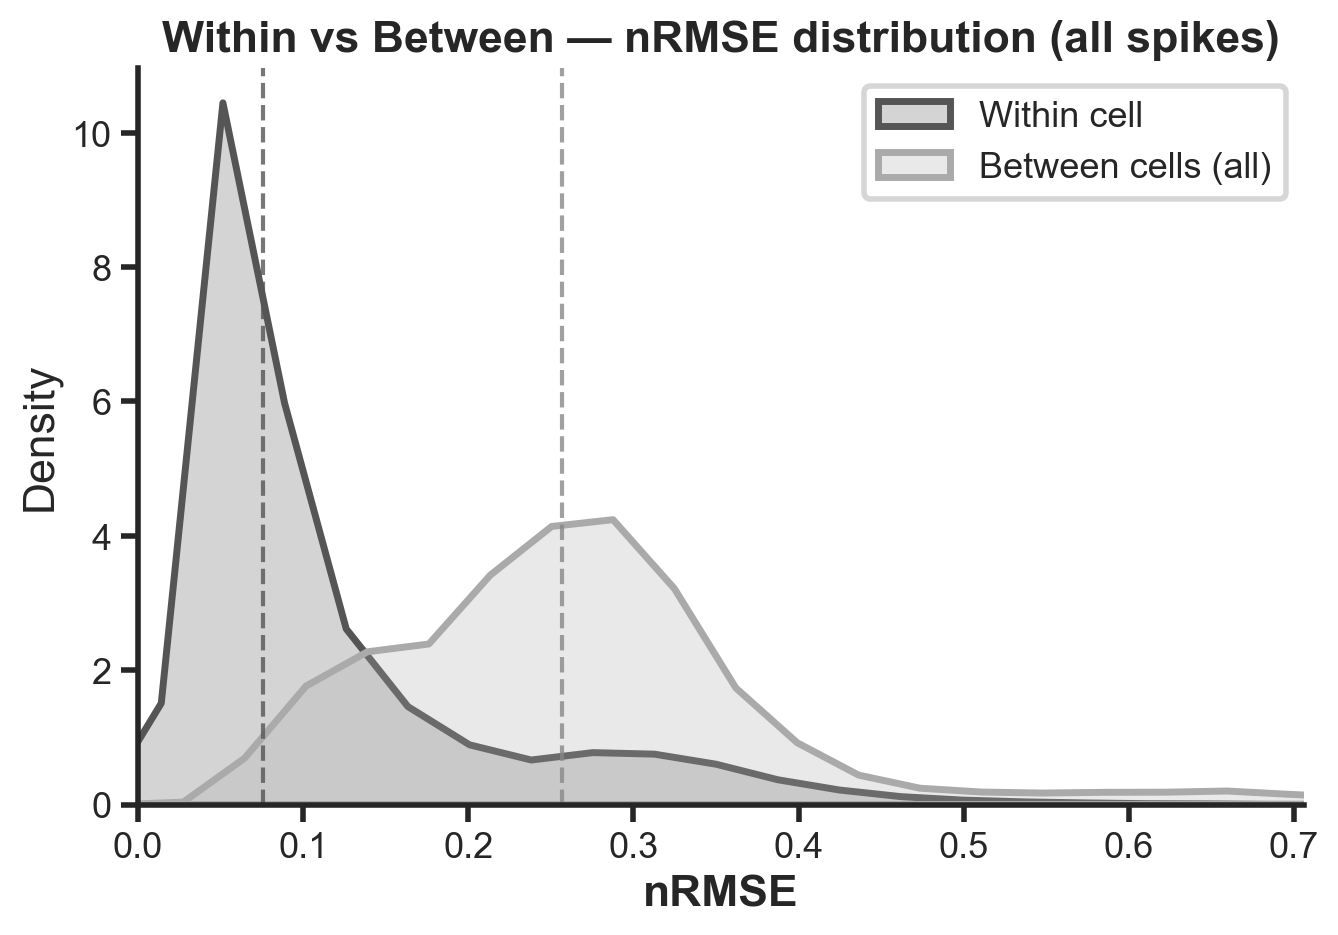

In [11]:
plot_waveform_dist_kde(df_master, wf_dir=cluster_pickle_dir, spike_fit_dir=spike_fit_dir)

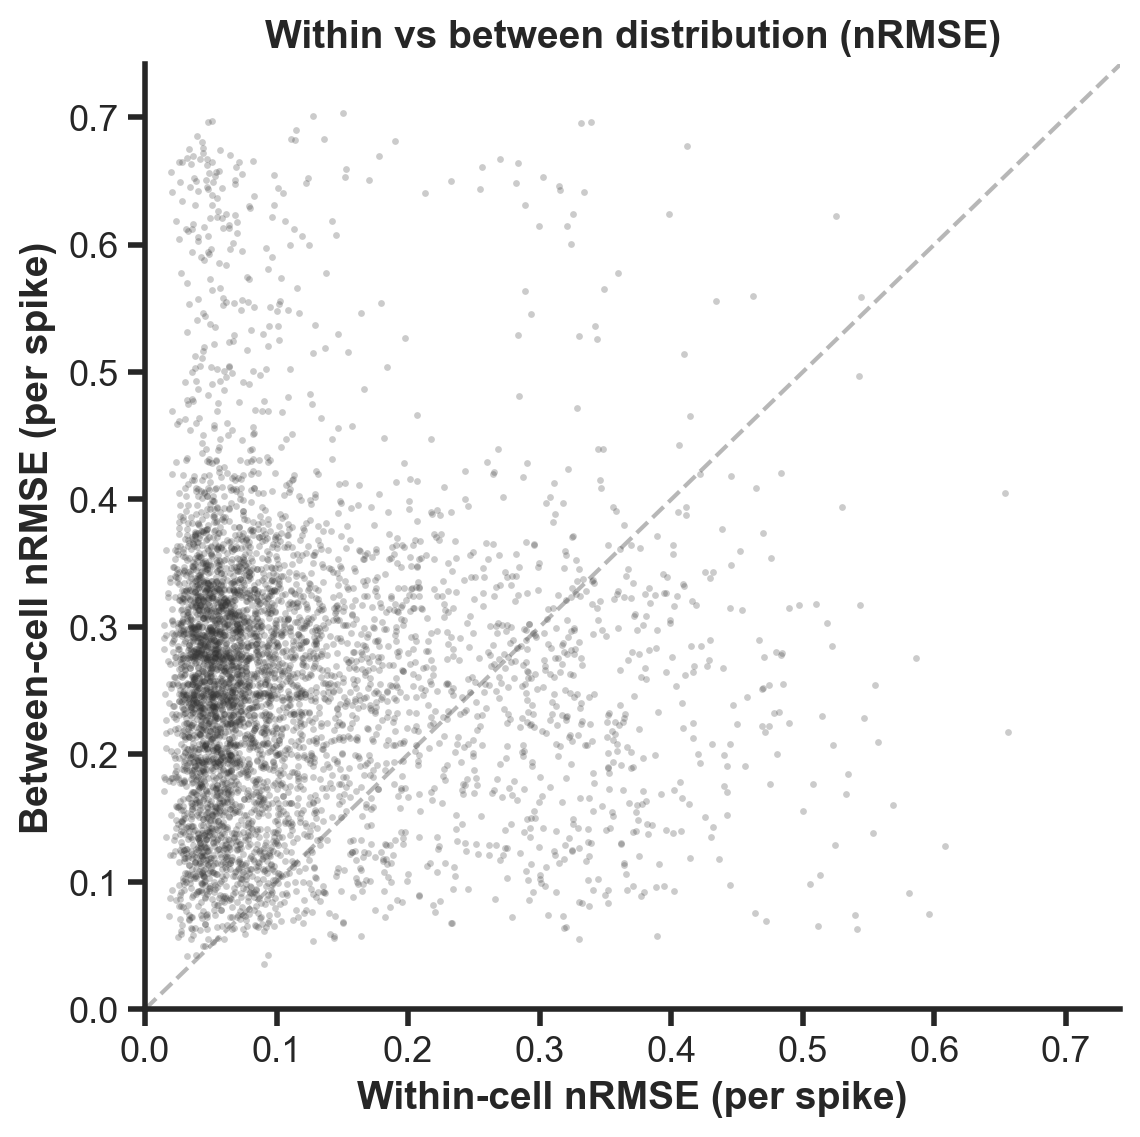

In [12]:
plot_waveform_dist_scatter(df_master, wf_dir=cluster_pickle_dir, spike_fit_dir=spike_fit_dir)

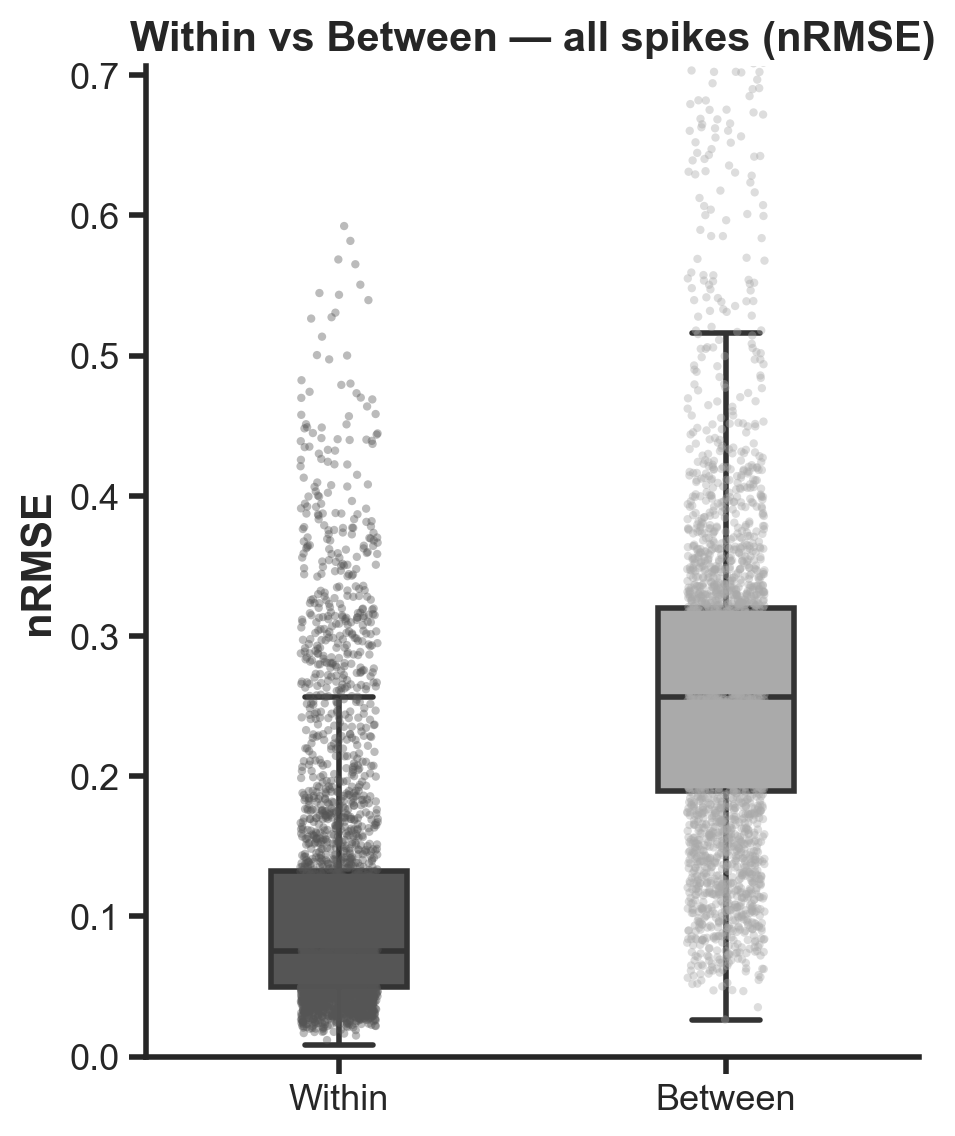

In [13]:
plot_waveform_dist_raincloud(df_master, wf_dir=cluster_pickle_dir, spike_fit_dir=spike_fit_dir)